# Context

In this notebook we will develop some exploratory data analysis

# Load packages

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# from scipy.stats import chi2_contingency
import warnings

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

# Load data

using relative paths

In [88]:
filename = "EDA_regression.ipynb"  # Current file name
print(f"Current file name: {filename}\n")
print(f"Current absolute path: {os.getcwd()}\n")

# Specify the paths, relative to the current file
ACTUAL_DIR = os.path.dirname(os.path.abspath(filename))
BASE_DIR = os.path.dirname(ACTUAL_DIR)
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(DATA_DIR, "output_data")

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

Current file name: EDA_regression.ipynb

Current absolute path: c:\Users\jhona\Dropbox\ASPECTOS MAESTRIA\Cursos semestres\SEMESTRE 1\Aprendizaje automatico 1\PROYECTO FINAL\ML1_industria_azucarera\notebooks

BASE_DIR: c:\Users\jhona\Dropbox\ASPECTOS MAESTRIA\Cursos semestres\SEMESTRE 1\Aprendizaje automatico 1\PROYECTO FINAL\ML1_industria_azucarera
DATA_DIR: c:\Users\jhona\Dropbox\ASPECTOS MAESTRIA\Cursos semestres\SEMESTRE 1\Aprendizaje automatico 1\PROYECTO FINAL\ML1_industria_azucarera\data
OUTPUT_DIR: c:\Users\jhona\Dropbox\ASPECTOS MAESTRIA\Cursos semestres\SEMESTRE 1\Aprendizaje automatico 1\PROYECTO FINAL\ML1_industria_azucarera\data\output_data


In [89]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, "suertes_for_reg.csv")).iloc[:, 1:]

df.head(5)

,tch,zona,dist_km,cult_organico,num_cosechas,edad_ult_cos,edad_precosecha,vejez,pct_infest_diatrea,dosis_madurante,semanas_mad_,ddult_riego,num_riegos,lluvias_2_meses_ant_,lluvias_0__3,lluvias_tres_a_seis,lluvias_seis_a_nueve,lluvias_9_a_cos,lluvias_ciclo,tipo_quema,t_corte,temp__media_0_3,temp__media_ciclo,temp_max_ciclo,temp_min_ciclo,humedad_rel_media_0_3,humedad_rel_media_ciclo,oscilacion_temp_med_0_3,oscilacion_temp_ciclo,radicion_solar_0_3,radiacion_solar_ciclo,precipitacion_0_3,precipitacion_ciclo,evaporacion_0_3,evaporacion_ciclo,urea_46pct_,mez,boro_granul_,microzinc,nito_xtend,sul_amonio,nitrax_s,rango_edad_ult_cos,m3_riego_p_ha,edad_siembra_a_ult_cos,variedad_v2,producto_categoria,algun_fertilizante,agua_total_l_ha,vinaza_p_ha
0,149.714285,ip06,7.5,0.0,1,12.68,11.27,NaN,NaN,NaN,NaN,148.0,1.0,192.0,110.0,369.0,103.0,403.0,985.0,verde,manual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158.730159,39.682540,NaN,NaN,NaN,NaN,NaN,11-12 meses,2054.285714,21.618070,cc_mayor_2000,No especificado,1,1.190429e+07,8730.158730
1,129.673316,ip06,7.5,0.0,8,12.02,10.58,15.540,NaN,NaN,NaN,103.0,3.0,192.0,190.0,309.0,168.0,314.0,981.0,q_programada,manual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,149.625935,49.875312,19.950125,19.950125,NaN,NaN,NaN,11-12 meses,4977.680798,114.398357,cc_menor_2000,No especificado,1,1.478768e+07,2244.389027
2,139.855072,ip06,7.5,0.0,1,12.48,10.81,1.930,NaN,1.0,6.571428,133.0,2.0,172.0,180.0,307.0,149.0,345.0,981.0,verde,mecanizado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.618357,48.309179,NaN,NaN,NaN,NaN,NaN,11-12 meses,2383.130435,23.260780,cc_mayor_2000,Madurante,1,1.219313e+07,NaN
3,157.754901,ip06,7.5,0.0,3,12.09,10.68,10.312,NaN,1.0,5.428571,114.0,4.0,298.0,348.0,345.0,182.0,476.0,1351.0,verde,manual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,147.058824,49.019608,NaN,NaN,NaN,NaN,NaN,11-12 meses,10912.045752,41.626283,others,Madurante,1,2.442205e+07,3921.568627
4,127.289256,ip06,7.5,0.0,1,12.12,10.71,NaN,NaN,NaN,NaN,89.0,5.0,149.0,280.0,308.0,152.0,298.0,1038.0,verde,manual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11-12 meses,7757.000000,23.556468,cc_menor_2000,No especificado,0,1.813700e+07,NaN


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20126 entries, 0 to 20125
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tch                      20126 non-null  float64
 1   zona                     20126 non-null  object 
 2   dist_km                  20121 non-null  float64
 3   cult_organico            20124 non-null  float64
 4   num_cosechas             20126 non-null  int64  
 5   edad_ult_cos             20126 non-null  float64
 6   edad_precosecha          8745 non-null   float64
 7   vejez                    17963 non-null  float64
 8   pct_infest_diatrea       5470 non-null   float64
 9   dosis_madurante          13629 non-null  float64
 10  semanas_mad_             13629 non-null  float64
 11  ddult_riego              12547 non-null  float64
 12  num_riegos               12542 non-null  float64
 13  lluvias_2_meses_ant_     18102 non-null  float64
 14  lluvias_0__3          

In [91]:
# Estilos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Análisis univariado de datos

### Variable objetivo

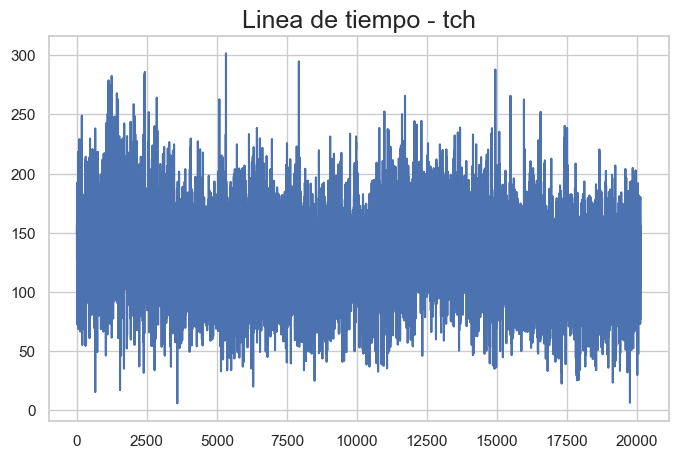

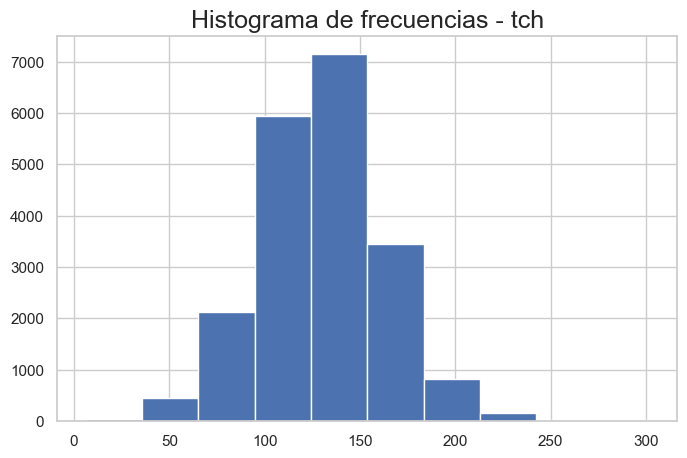

In [92]:
df.tch.plot()
plt.title("Linea de tiempo - tch", size=18)
plt.show()

df.tch.hist()
plt.title("Histograma de frecuencias - tch", size=18)
plt.show()

### Variables categóricas: conteo de frecuencias


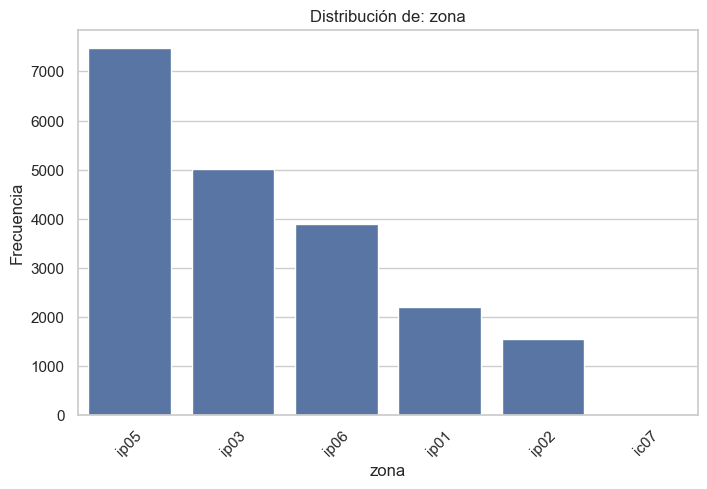

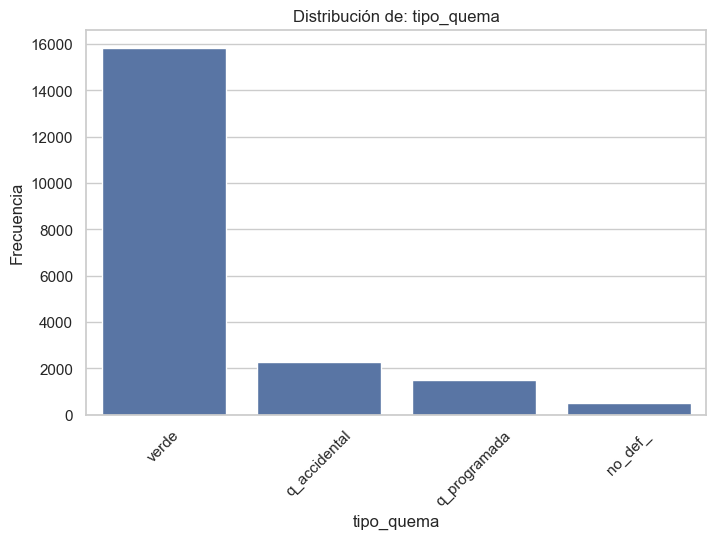

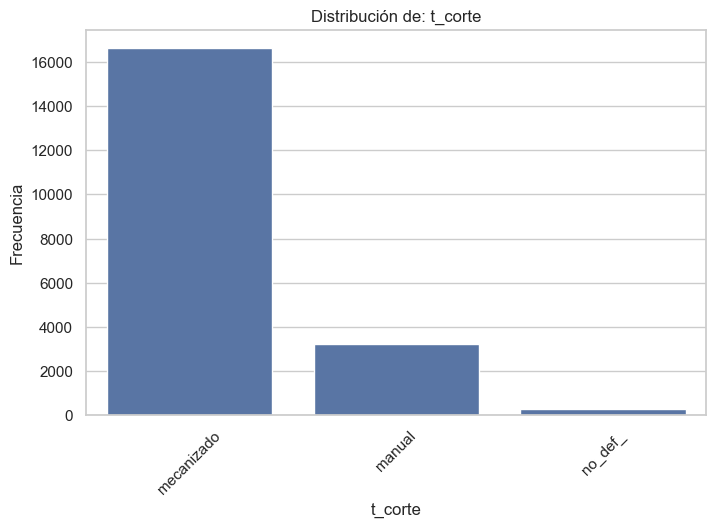

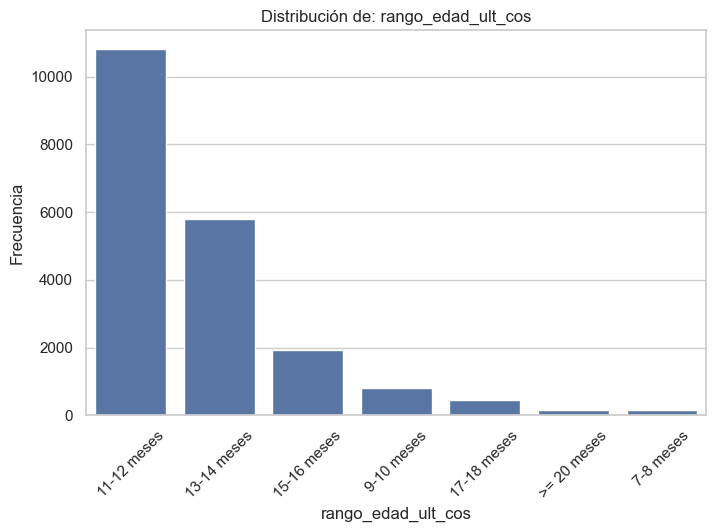

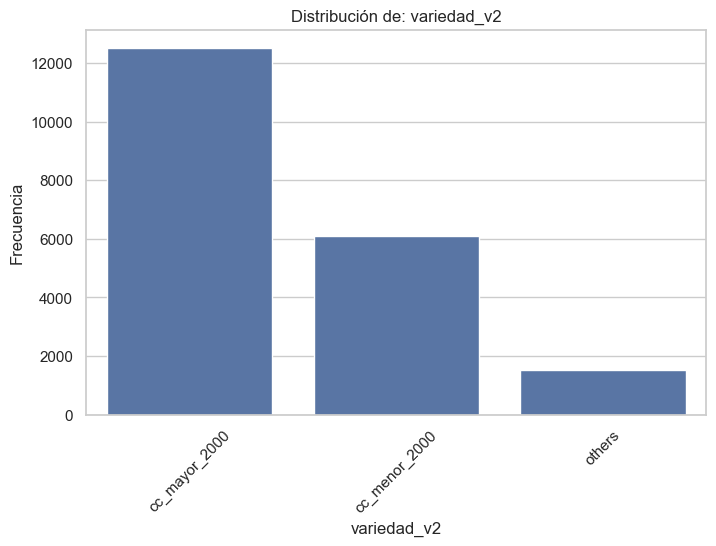

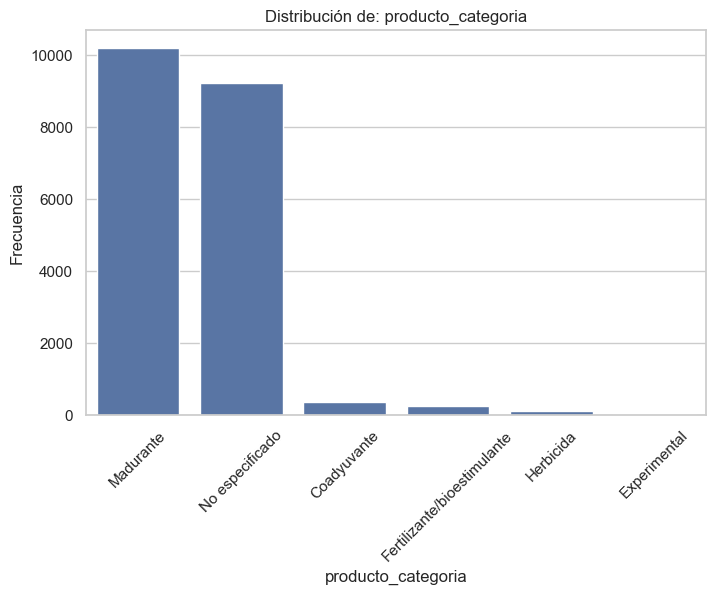

In [93]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    value_counts = df[col].value_counts()
    num_levels = len(value_counts)

    plt.figure(figsize=(8, 5))

    if num_levels < 10:
        sns.barplot(x=value_counts.index, y=value_counts.values)
        plt.xticks(rotation=45)
    else:
        sns.barplot(y=value_counts.index, x=value_counts.values, orient="h")

    plt.title(f"Distribución de: {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

### Analisis variables numéricas


In [94]:
# Resumen estadístico de variables numéricas
print("Resumen estadístico:")
display(df.describe())

Resumen estadístico:


,tch,dist_km,cult_organico,num_cosechas,edad_ult_cos,edad_precosecha,vejez,pct_infest_diatrea,dosis_madurante,semanas_mad_,ddult_riego,num_riegos,lluvias_2_meses_ant_,lluvias_0__3,lluvias_tres_a_seis,lluvias_seis_a_nueve,lluvias_9_a_cos,lluvias_ciclo,temp__media_0_3,temp__media_ciclo,temp_max_ciclo,temp_min_ciclo,humedad_rel_media_0_3,humedad_rel_media_ciclo,oscilacion_temp_med_0_3,oscilacion_temp_ciclo,radicion_solar_0_3,radiacion_solar_ciclo,precipitacion_0_3,precipitacion_ciclo,evaporacion_0_3,evaporacion_ciclo,urea_46pct_,mez,boro_granul_,microzinc,nito_xtend,sul_amonio,nitrax_s,m3_riego_p_ha,edad_siembra_a_ult_cos,algun_fertilizante,agua_total_l_ha,vinaza_p_ha
count,20126.000000,20121.000000,20124.000000,20126.000000,20126.000000,8745.000000,17963.000000,5470.000000,13629.000000,13629.000000,12547.000000,12542.000000,18102.000000,18102.000000,18102.000000,18102.000000,18102.000000,18102.000000,6181.000000,6181.000000,6181.000000,6181.000000,6181.000000,6181.000000,6181.000000,6181.000000,6181.000000,6181.000000,6181.000000,6181.000000,6181.000000,6181.000000,3263.000000,3004.000000,3012.000000,2956.000000,4728.000000,2561.000000,2040.000000,12547.000000,20126.000000,20126.000000,1.810200e+04,5554.000000
mean,130.232553,25.458883,0.034735,4.237951,13.057298,12.359089,12.091149,3.816000,1.001276,9.409687,114.343987,6.169590,115.838717,191.914967,189.291281,183.738147,256.797776,821.727421,23.354137,24.557860,34.621019,15.398963,81.117111,80.663086,16.062904,24.557860,434.956895,438.440943,296.373146,1202.499055,443.127984,1920.837763,4875.817283,86.644100,22.450026,24.461293,343.495266,294.661672,301.330921,6917.677015,67.040451,0.329872,1.301211e+07,3536.800535
std,32.359067,18.263904,0.183111,3.904114,1.726721,1.398884,20.794765,2.829145,0.285246,4.436689,86.561976,14.114329,94.207524,130.363897,133.320502,129.644973,222.666415,442.003343,1.138196,2.440012,0.971845,0.467838,2.693456,2.637583,1.268903,2.440012,20.264795,17.802201,98.673828,320.713149,40.740965,262.832437,61544.635715,84.891602,34.672799,34.329517,688.971378,338.077661,477.091645,7632.260373,48.784864,0.470178,8.742454e+06,13747.291386
min,5.989178,1.100000,0.000000,0.000000,7.590000,0.000000,0.017000,0.000000,0.300000,0.857142,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,22.040000,22.353000,32.600000,13.900000,60.341000,63.327000,12.500000,22.353000,352.013000,367.315000,23.100000,23.100000,190.400000,190.400000,9.025271,1.851852,0.714286,0.714286,1.928268,1.153213,0.115407,0.000000,10.480493,0.000000,1.000000e+05,1.931330
25%,109.405377,12.000000,0.000000,1.000000,11.990000,11.530000,2.107000,1.985925,0.800000,6.714285,57.000000,2.000000,46.000000,96.000000,90.666667,91.250000,101.000000,525.000000,22.886000,22.972000,33.700000,15.200000,79.956000,79.883000,15.200000,22.972000,421.068000,427.273000,225.900000,1005.600000,418.310526,1761.300000,100.379816,49.933422,10.256410,11.709602,158.465892,116.995074,128.880866,1752.889055,31.408624,0.000000,6.710000e+06,536.211169
50%,129.892619,22.000000,0.000000,3.000000,12.650000,12.090000,2.729000,3.144200,1.000000,8.571428,91.000000,5.000000,101.538462,179.000000,176.000000,167.428571,209.000000,794.000000,23.112000,23.208000,34.600000,15.400000,81.495000,81.227000,15.700000,23.208000,436.980000,439.004000,292.536364,1173.810000,442.366667,1896.321429,195.093946,66.708106,15.411706,17.421603,239.539349,250.000000,194.174757,5600.000000,54.340862,0.000000,1.274960e+07,1001.696296
75%,150.683529,32.700000,0.000000,6.000000,13.860000,12.940000,10.195500,4.805325,1.200000,11.071428,152.000000,7.000000,168.168972,277.000000,268.000000,262.000000,357.000000,1073.000000,23.336000,25.684000,35.400000,15.600000,82.978000,82.274000,16.746875,25.684000,448.284000,450.472000,364.218182,1365.500000,467.000000,2052.300000,281.979978,98.712330,22.481842,23.684364,375.000000,397.911004,246.327684,9520.668458,86.956879,1.000000,1.747252e+07,2318.946439
max,301.608000,155.000000,1.000000,23.000000,21.7

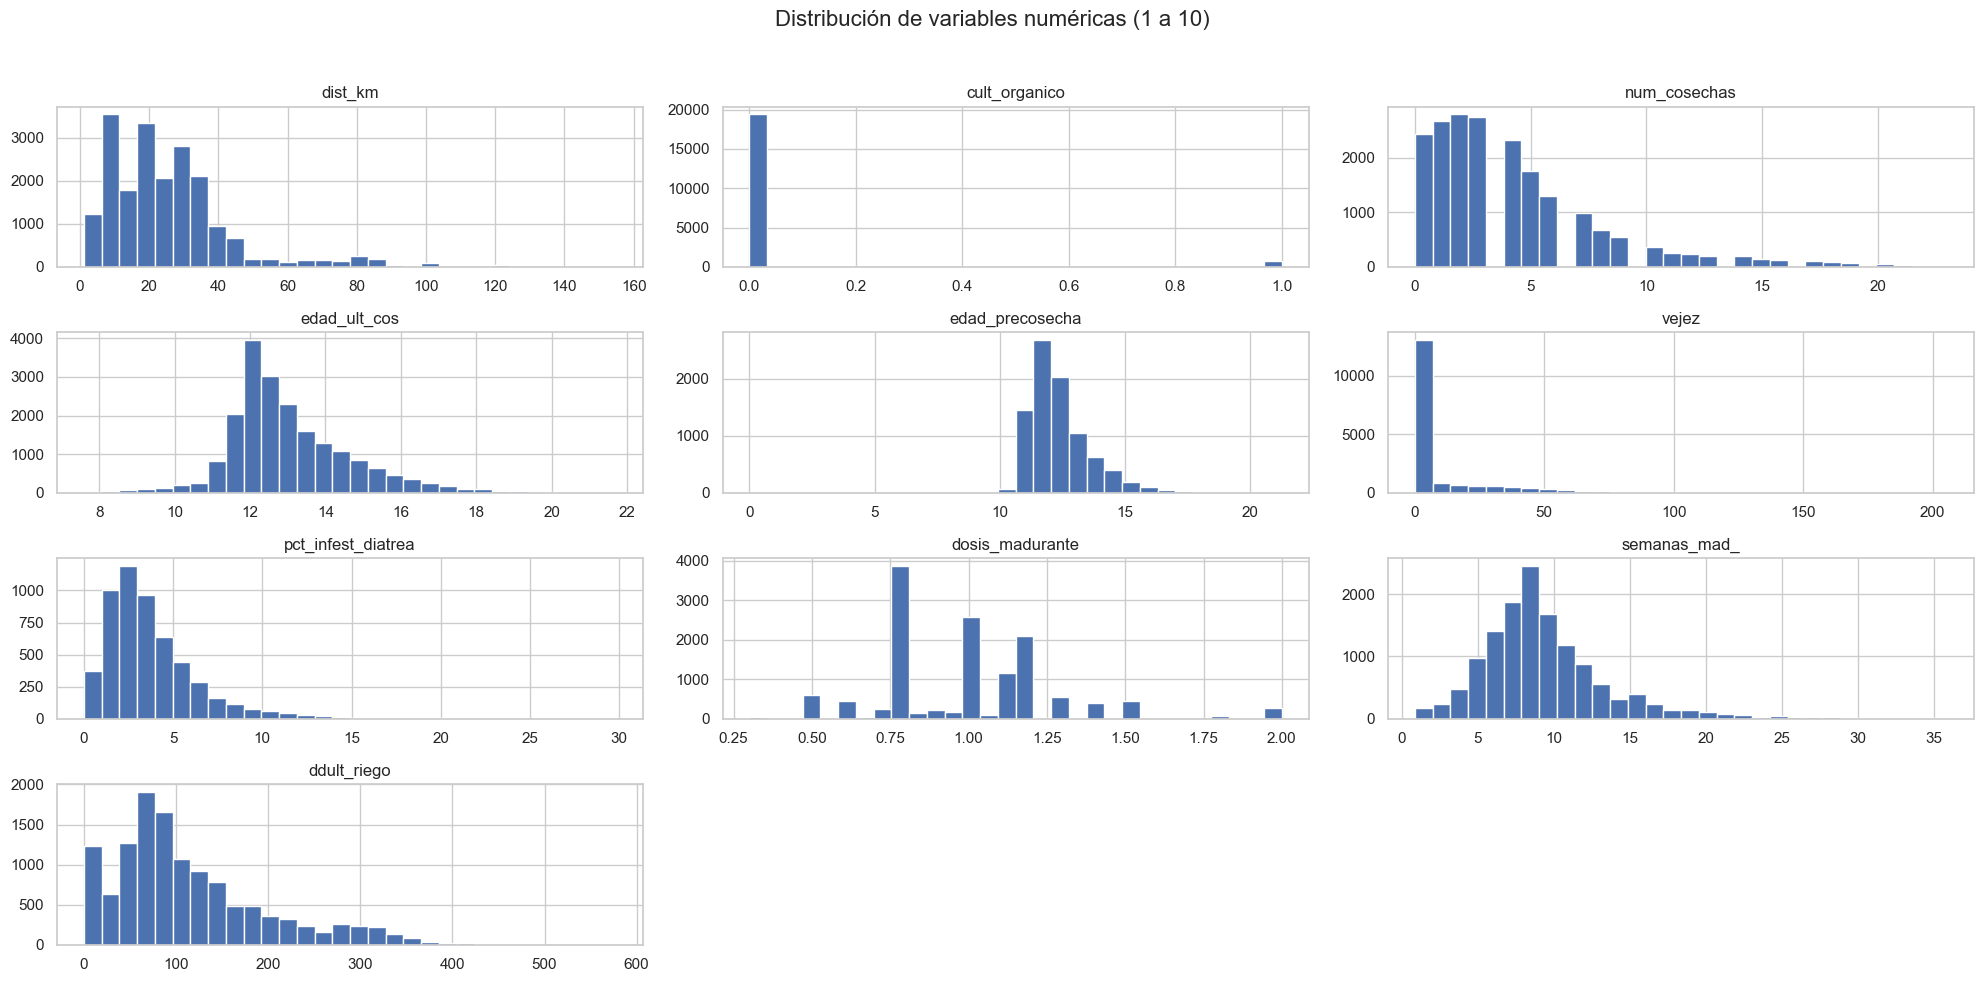

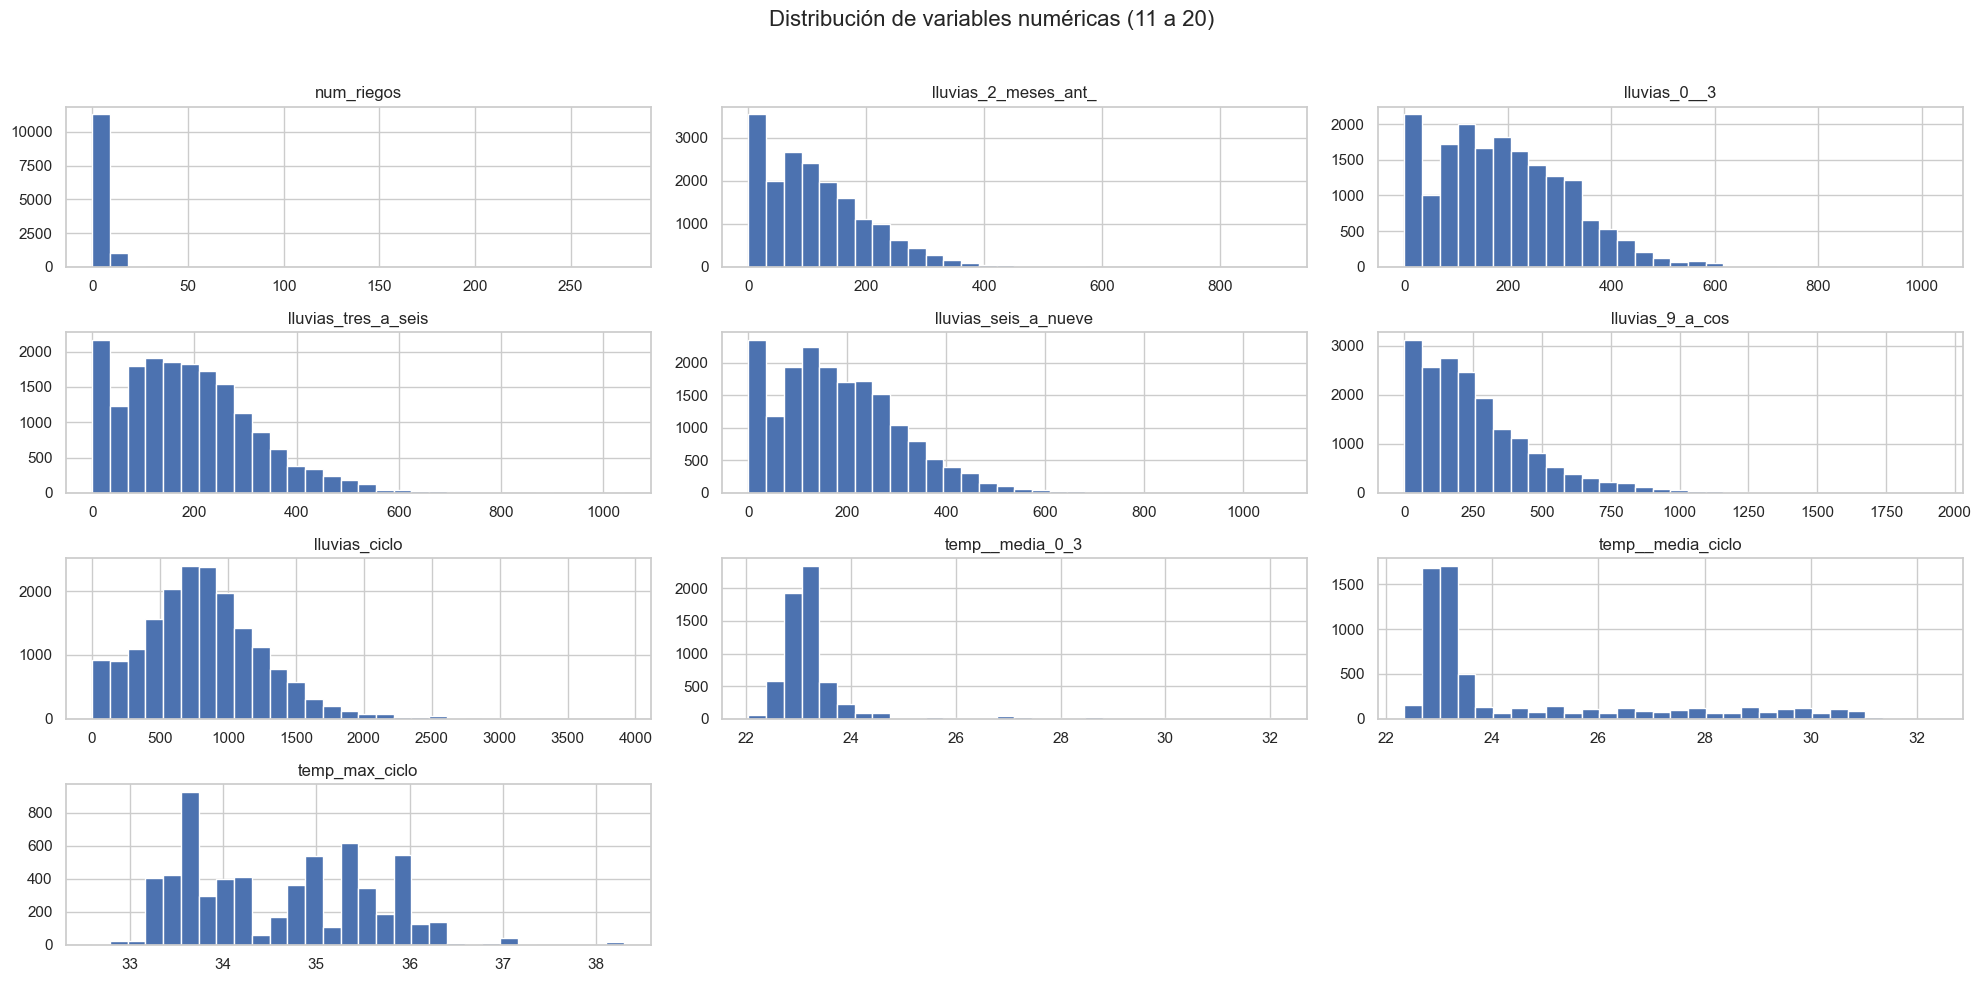

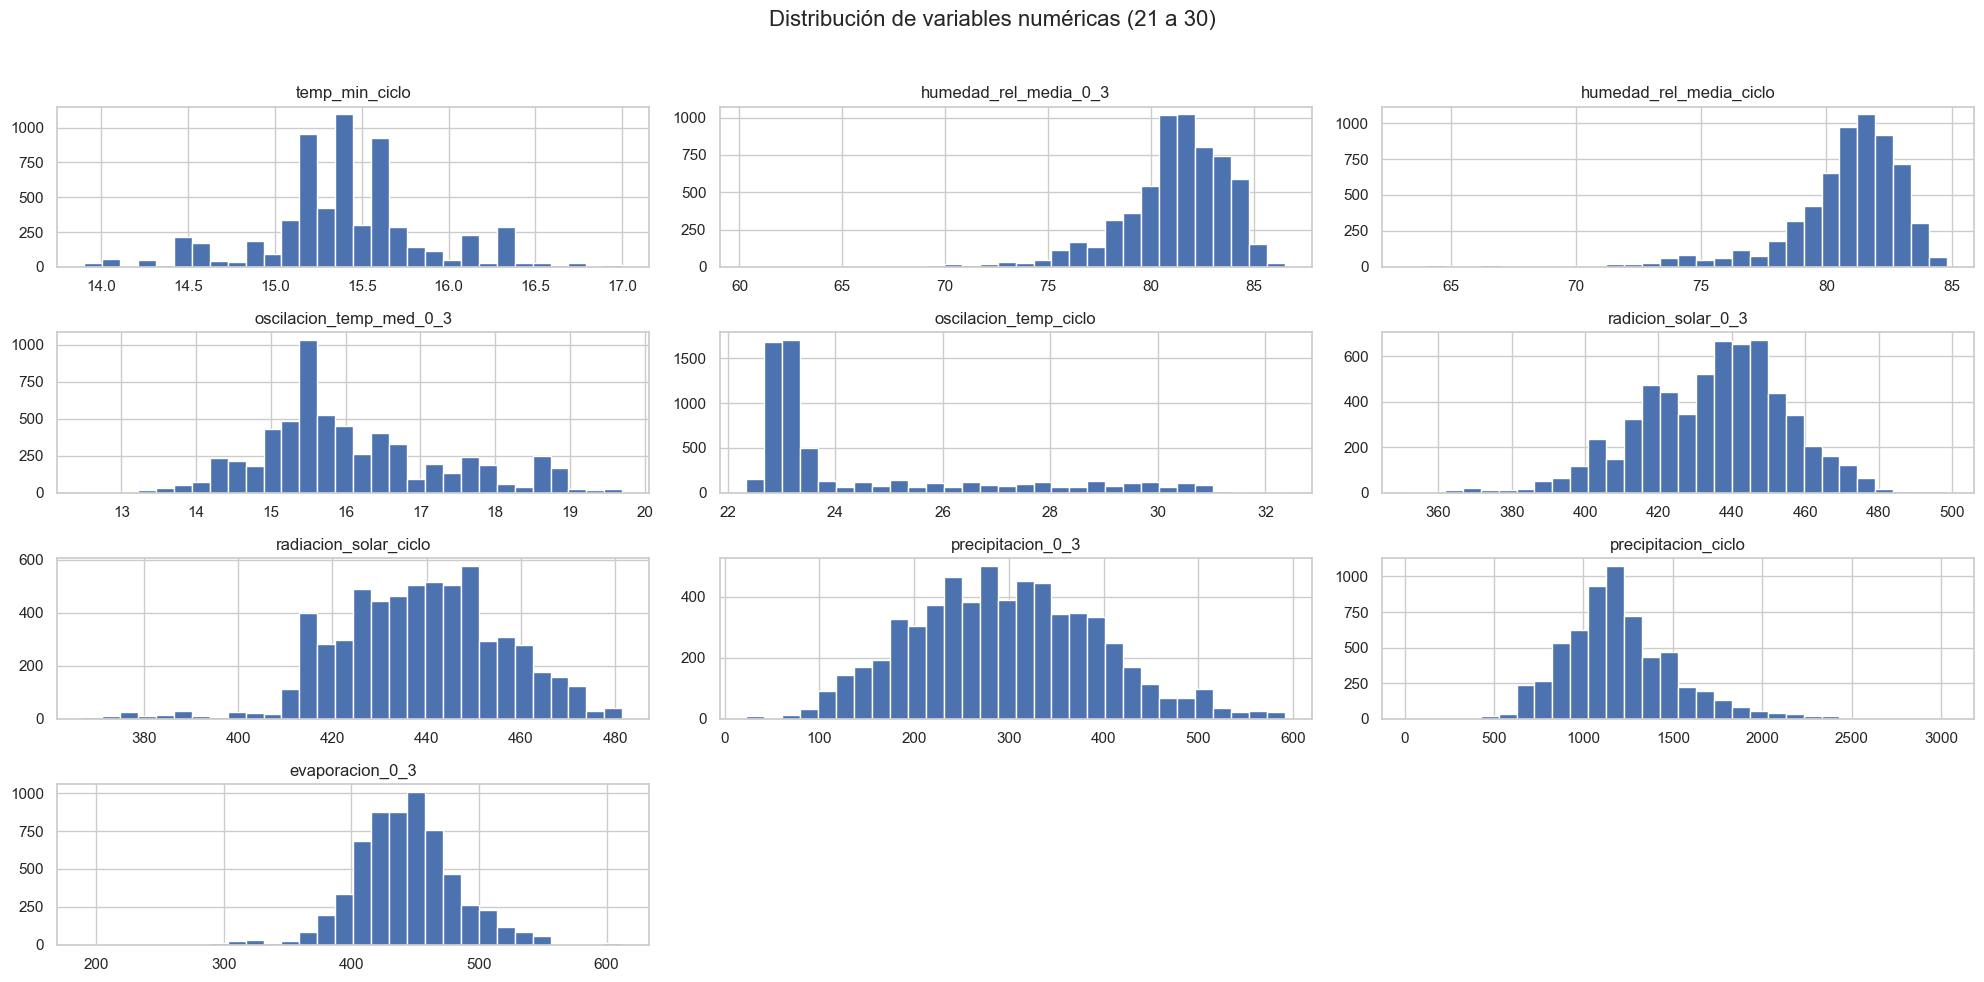

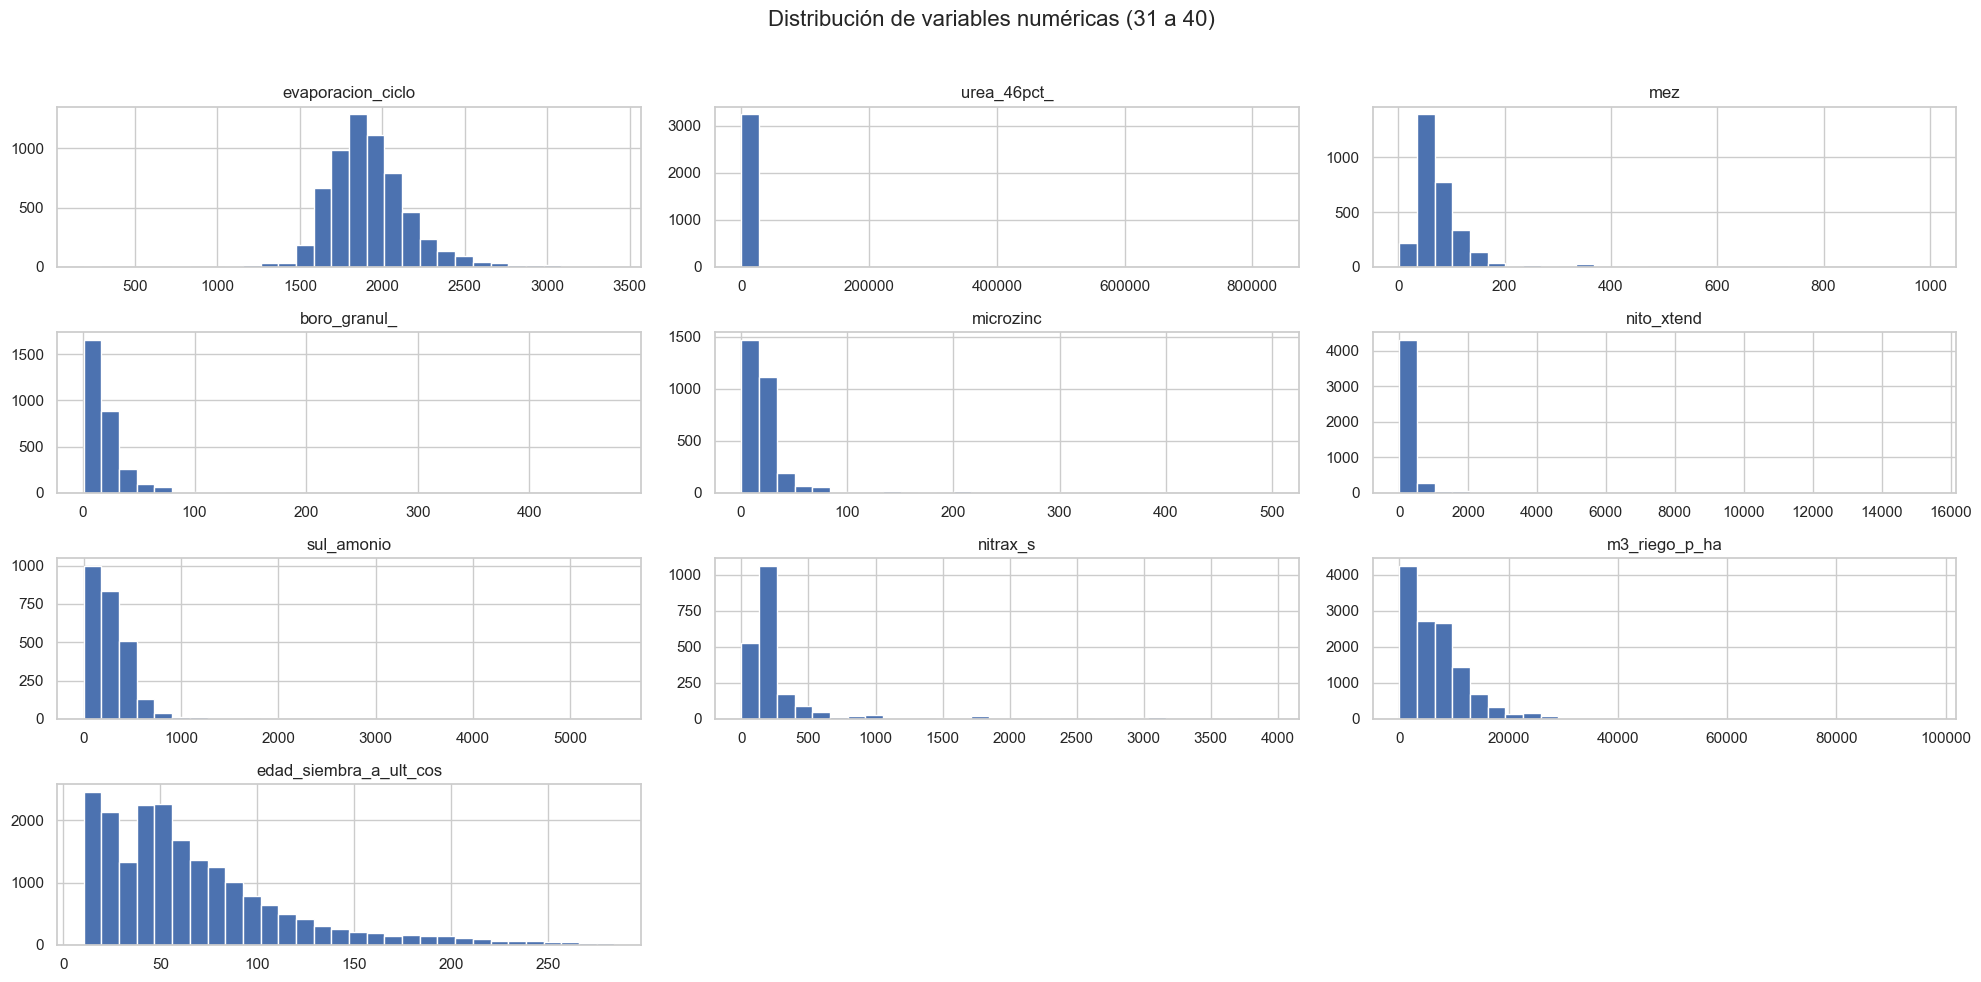

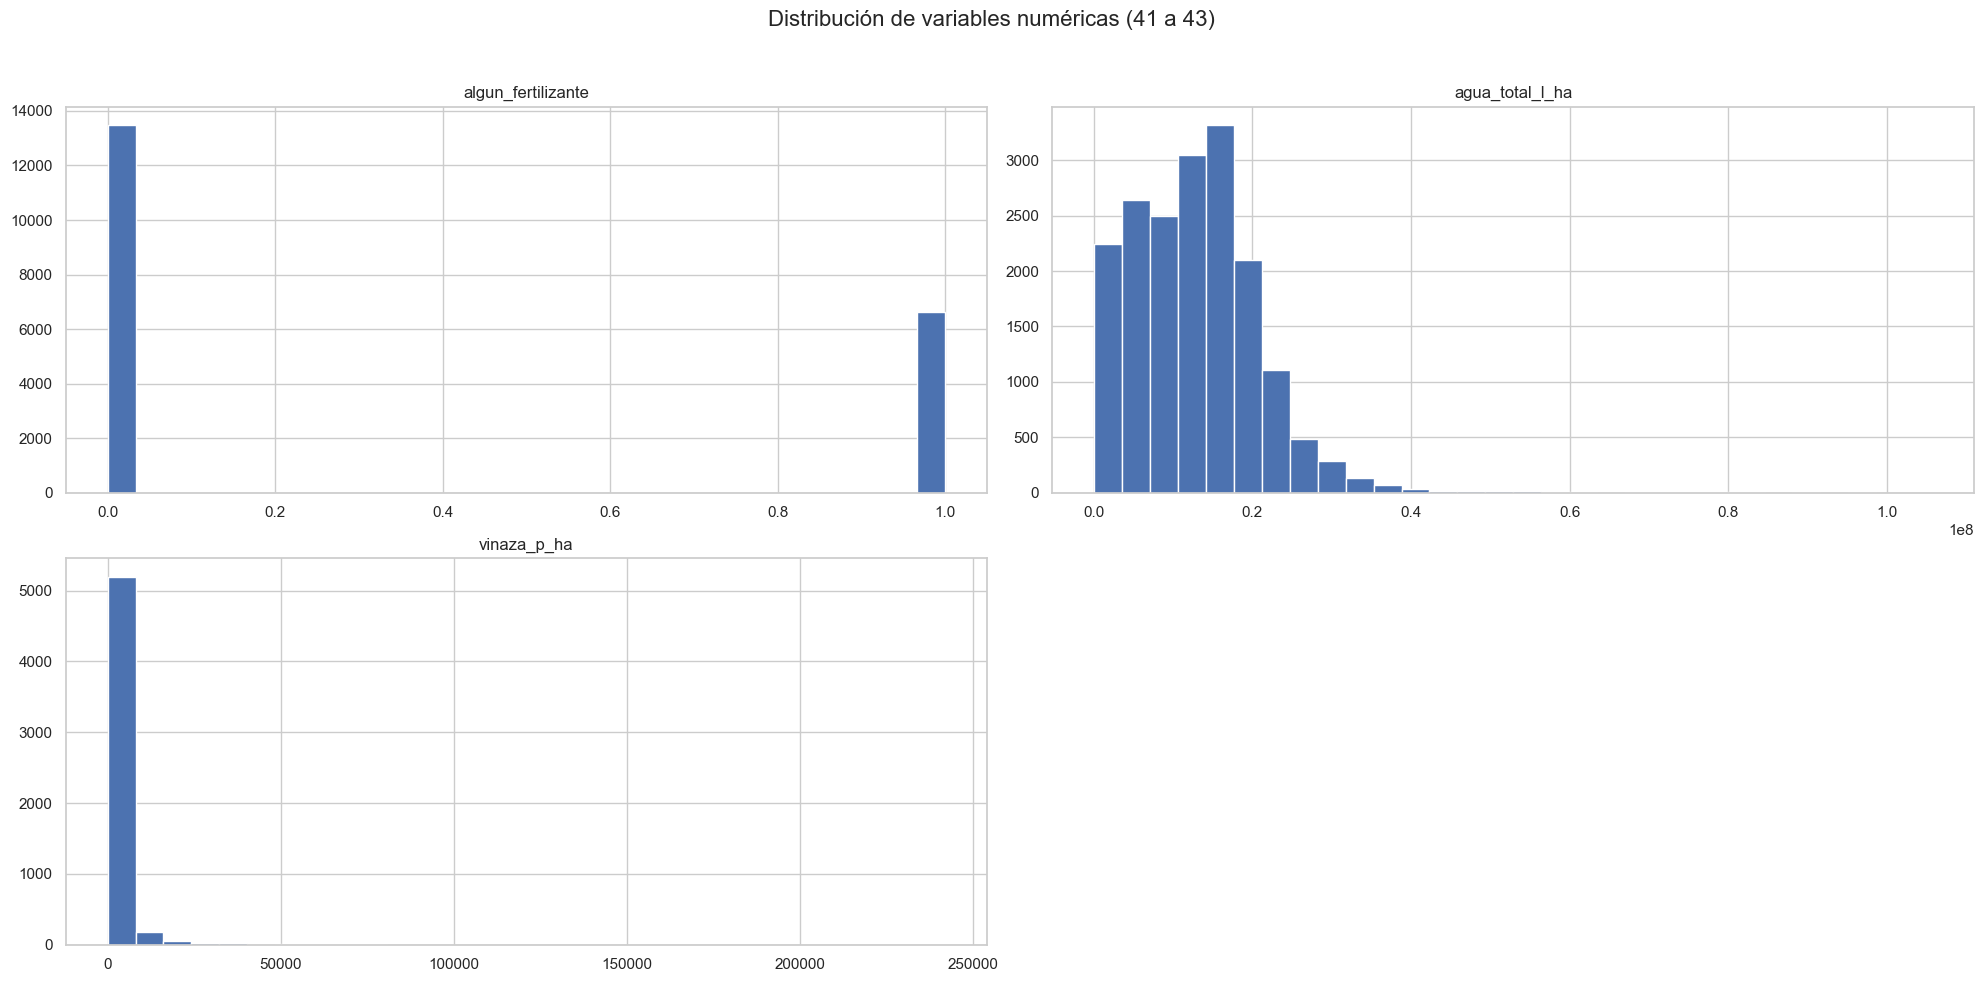

In [95]:
num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
num_cols.remove("tch")

# Graficar de a 10 variables por bloque
for i in range(0, len(num_cols), 10):
    subset = num_cols[i : i + 10]
    df[subset].hist(bins=30, figsize=(20, 10))
    plt.suptitle(
        f"Distribución de variables numéricas ({i+1} a {i+len(subset)})", fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # para que no se sobreponga el título
    plt.show()

# Analisis multivariado de datos

### Analisis de correlación - columnas numericas

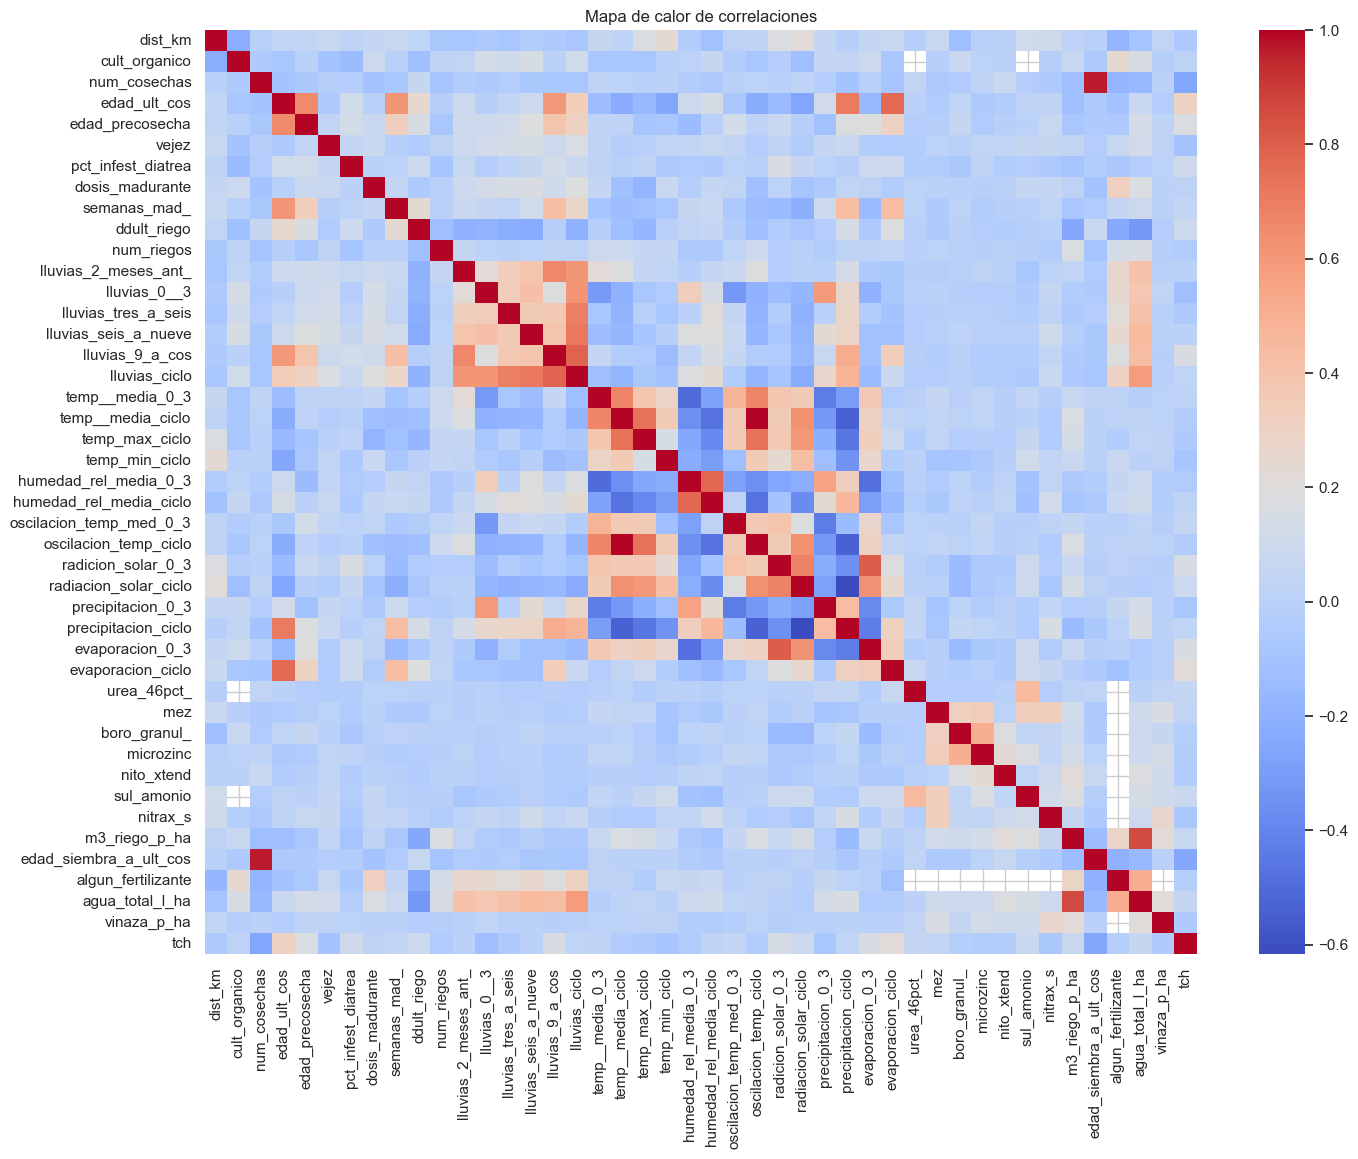

In [96]:
# ANÁLISIS BIVARIADO

# 4. Correlación entre variables numéricas
num_cols.append("tch")
cor_matrix = df[num_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(cor_matrix, cmap="coolwarm", annot=False)
plt.title("Mapa de calor de correlaciones")
plt.show()

#### TCH vs variables - total

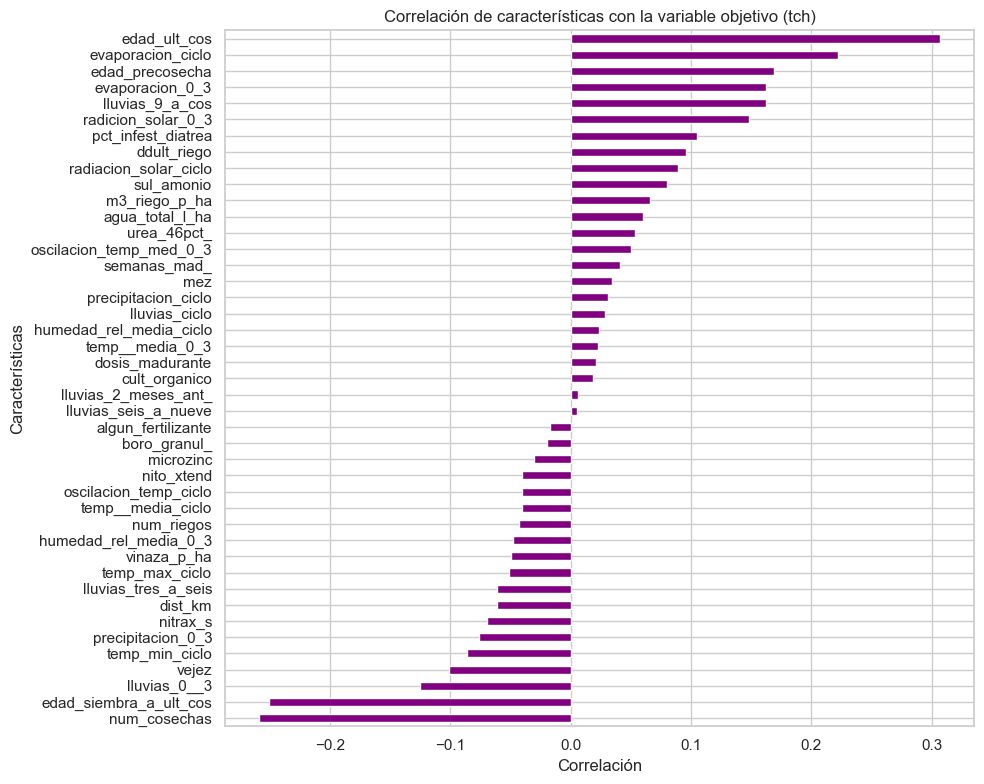

In [97]:
# Gráfico de barras para el análisis de correlación con la variable objetivo

corr_target = cor_matrix["tch"].drop("tch")

plt.figure(figsize=(10, 8))
corr_target.sort_values().plot(kind="barh", color="purple")
plt.title("Correlación de características con la variable objetivo (tch)")
plt.xlabel("Correlación")
plt.ylabel("Características")
plt.grid(True)
plt.tight_layout()
plt.show()

#### TCH vs variables - por variedad de caña > 2000

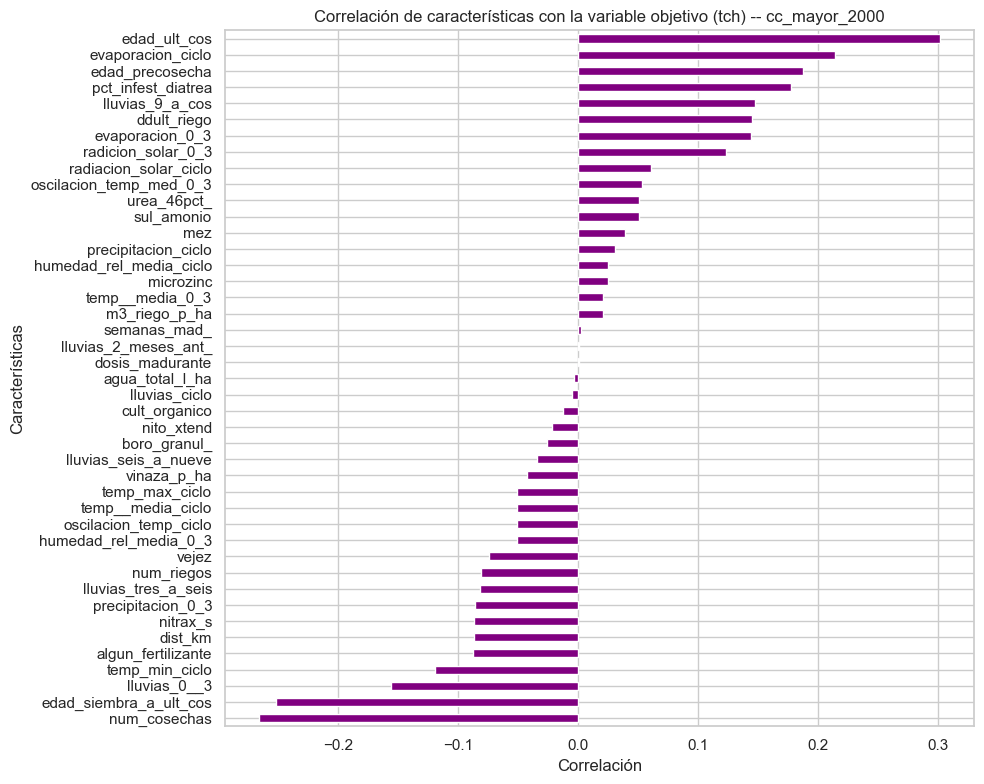

In [99]:
# Gráfico de barras para el análisis de correlación con la variable objetivo

cor_matrix = df[df["variedad_v2"] == "cc_mayor_2000"][num_cols].corr()
corr_target = cor_matrix["tch"].drop("tch")

plt.figure(figsize=(10, 8))
corr_target.sort_values().plot(kind="barh", color="purple")
plt.title(
    "Correlación de características con la variable objetivo (tch) -- cc_mayor_2000"
)
plt.xlabel("Correlación")
plt.ylabel("Características")
plt.grid(True)
plt.tight_layout()
plt.show()

#### TCH vs variables - por variedad de caña < 2000 y otros paises

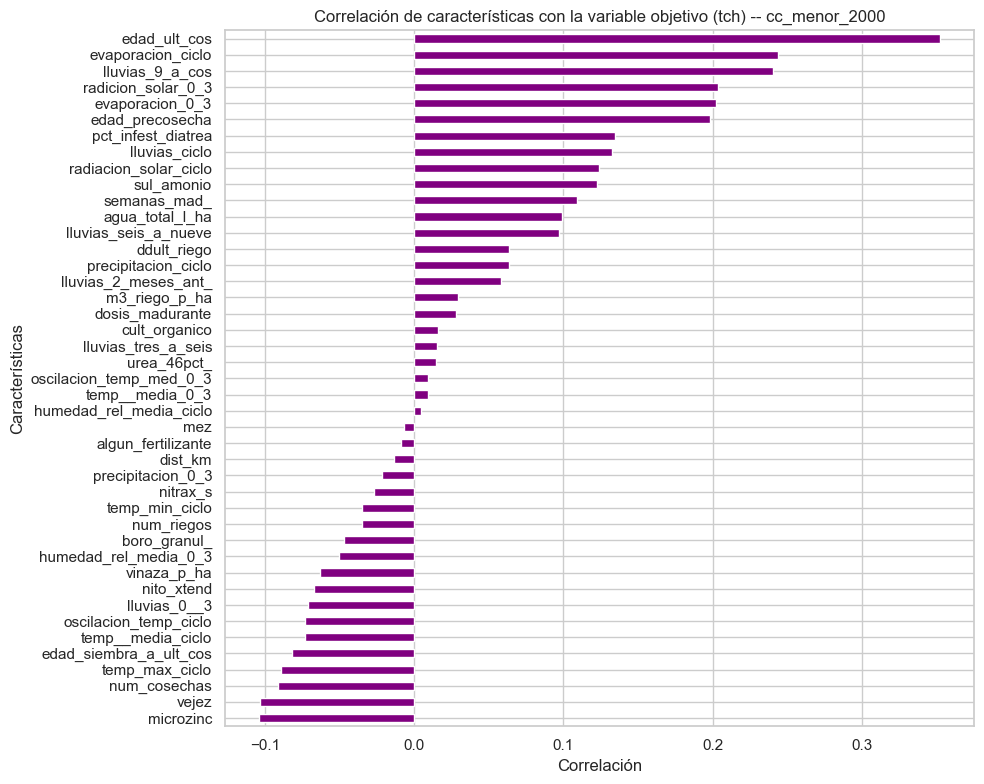

In [101]:
# Gráfico de barras para el análisis de correlación con la variable objetivo

cor_matrix = df[df["variedad_v2"] != "cc_mayor_2000"][num_cols].corr()
corr_target = cor_matrix["tch"].drop("tch")

plt.figure(figsize=(10, 8))
corr_target.sort_values().plot(kind="barh", color="purple")
plt.title(
    "Correlación de características con la variable objetivo (tch) -- cc_menor_2000"
)
plt.xlabel("Correlación")
plt.ylabel("Características")
plt.grid(True)
plt.tight_layout()
plt.show()

### TCH vs variables categoricas vs variedad caña

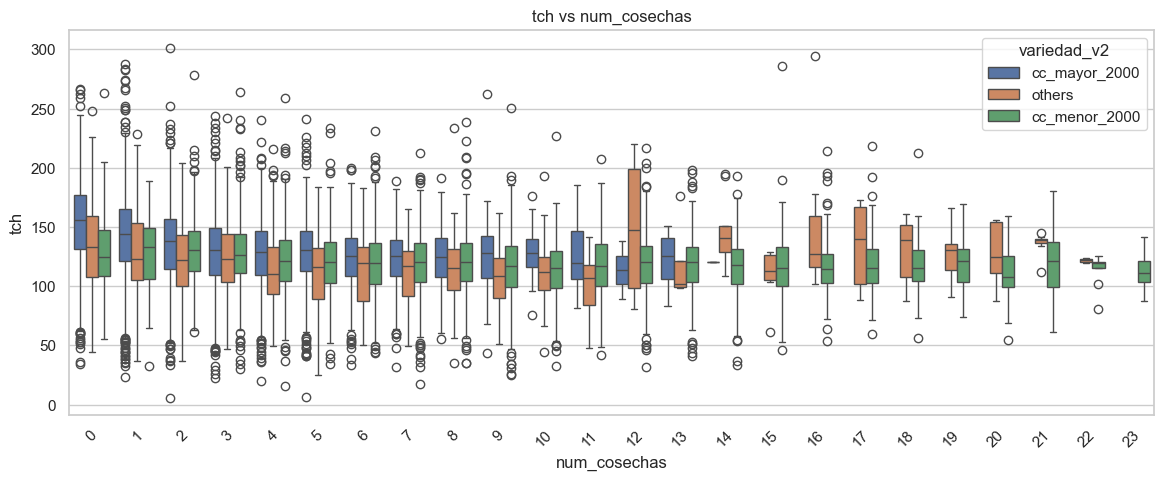

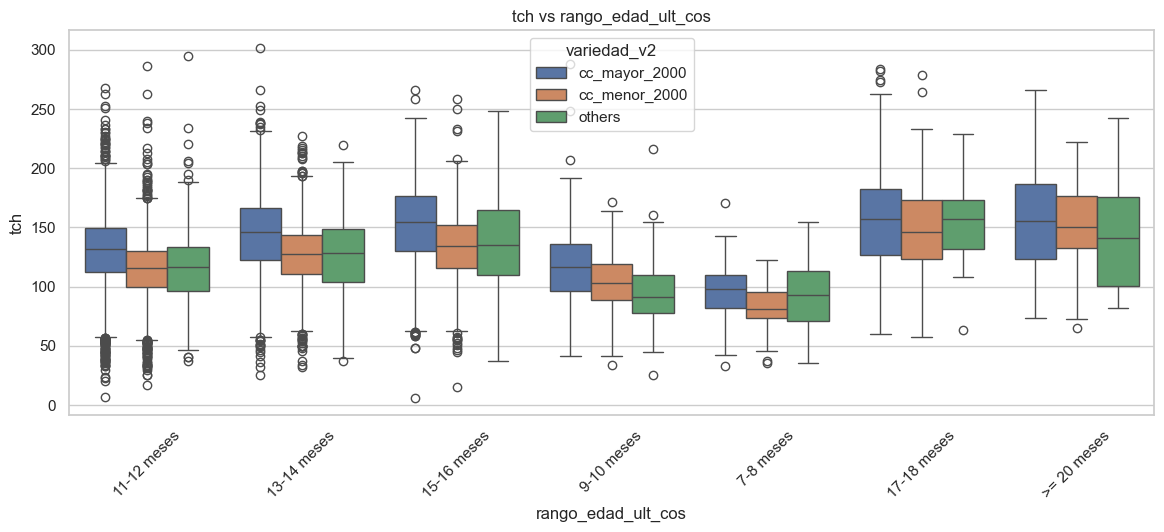

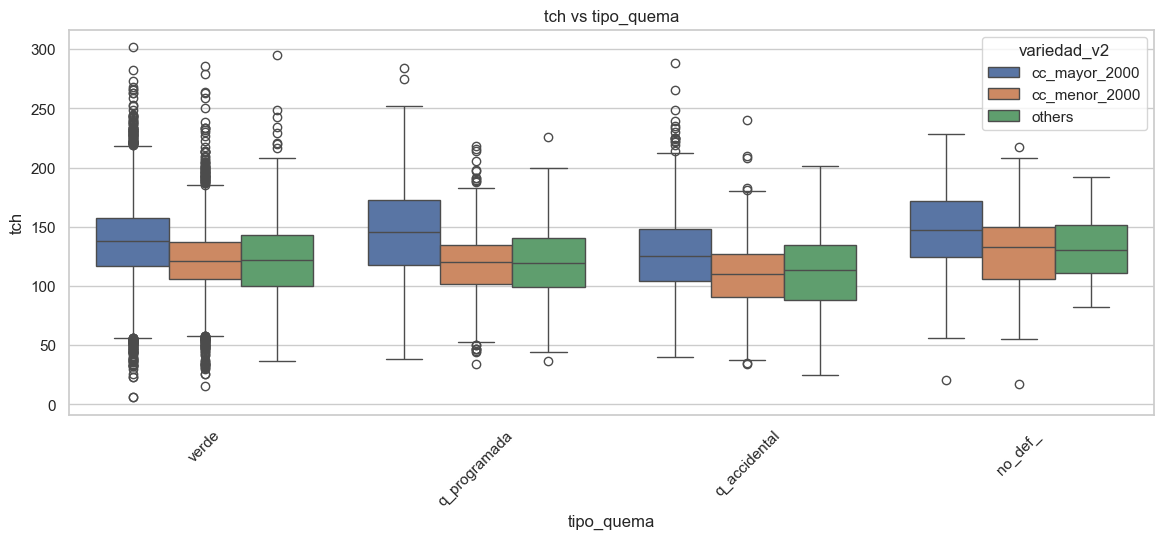

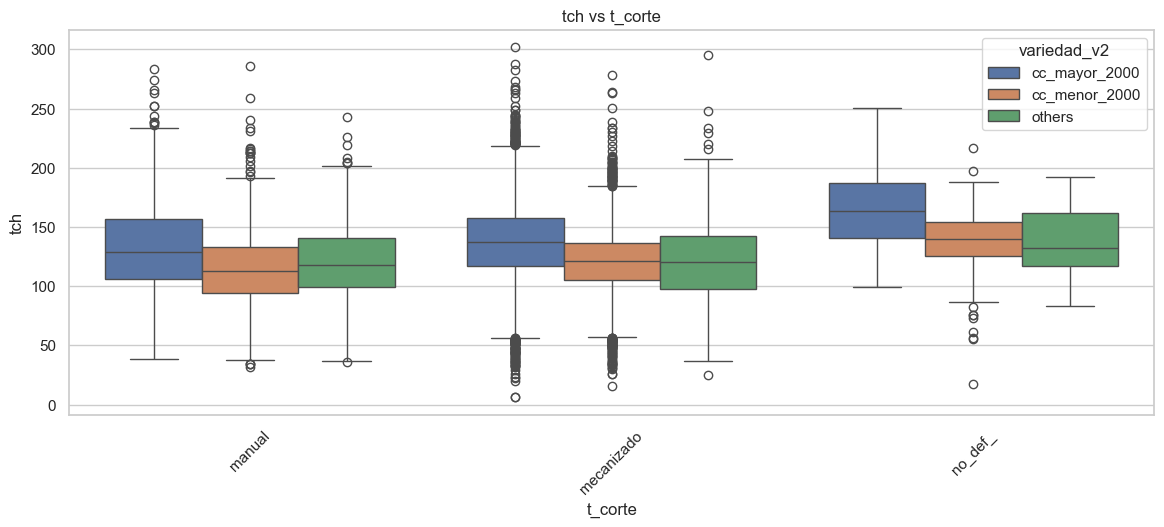

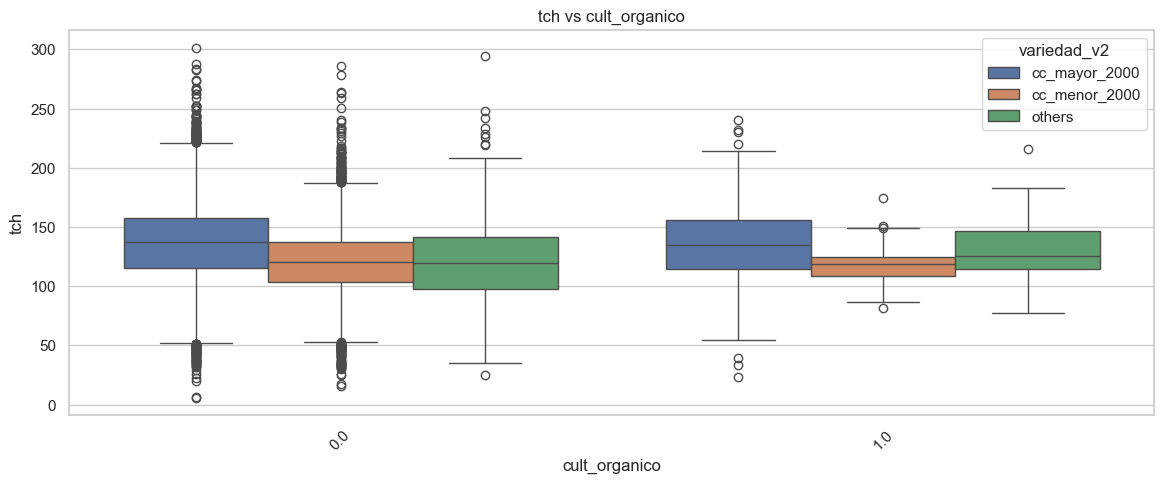

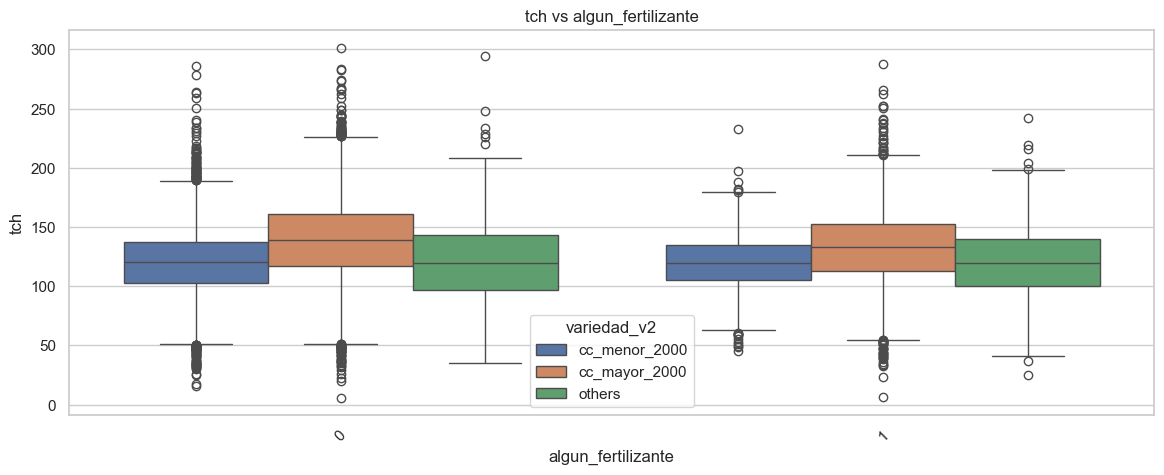

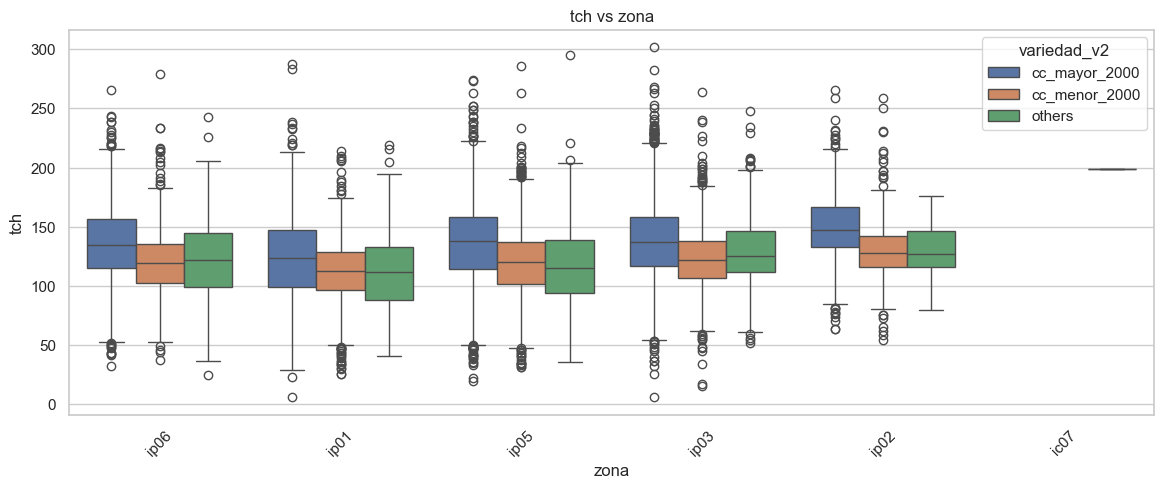

In [81]:
# 5. Boxplots de variables categóricas vs. TCH (rendimiento)
target = "tch"
cat_to_plot = [
    "num_cosechas",
    "rango_edad_ult_cos",
    "tipo_quema",
    "t_corte",
    "cult_organico",
    "algun_fertilizante",
    "zona",
]

for col in cat_to_plot:
    if col in df.columns:
        plt.figure(figsize=(14, 5))
        sns.boxplot(data=df, x=col, y=target, hue=df["variedad_v2"])
        plt.title(f"{target} vs {col}")
        plt.xticks(rotation=45)
        plt.show()

### TCH vs variables numericas

Solo las variables numericas con mayor valor absoluto de correlación de pearson

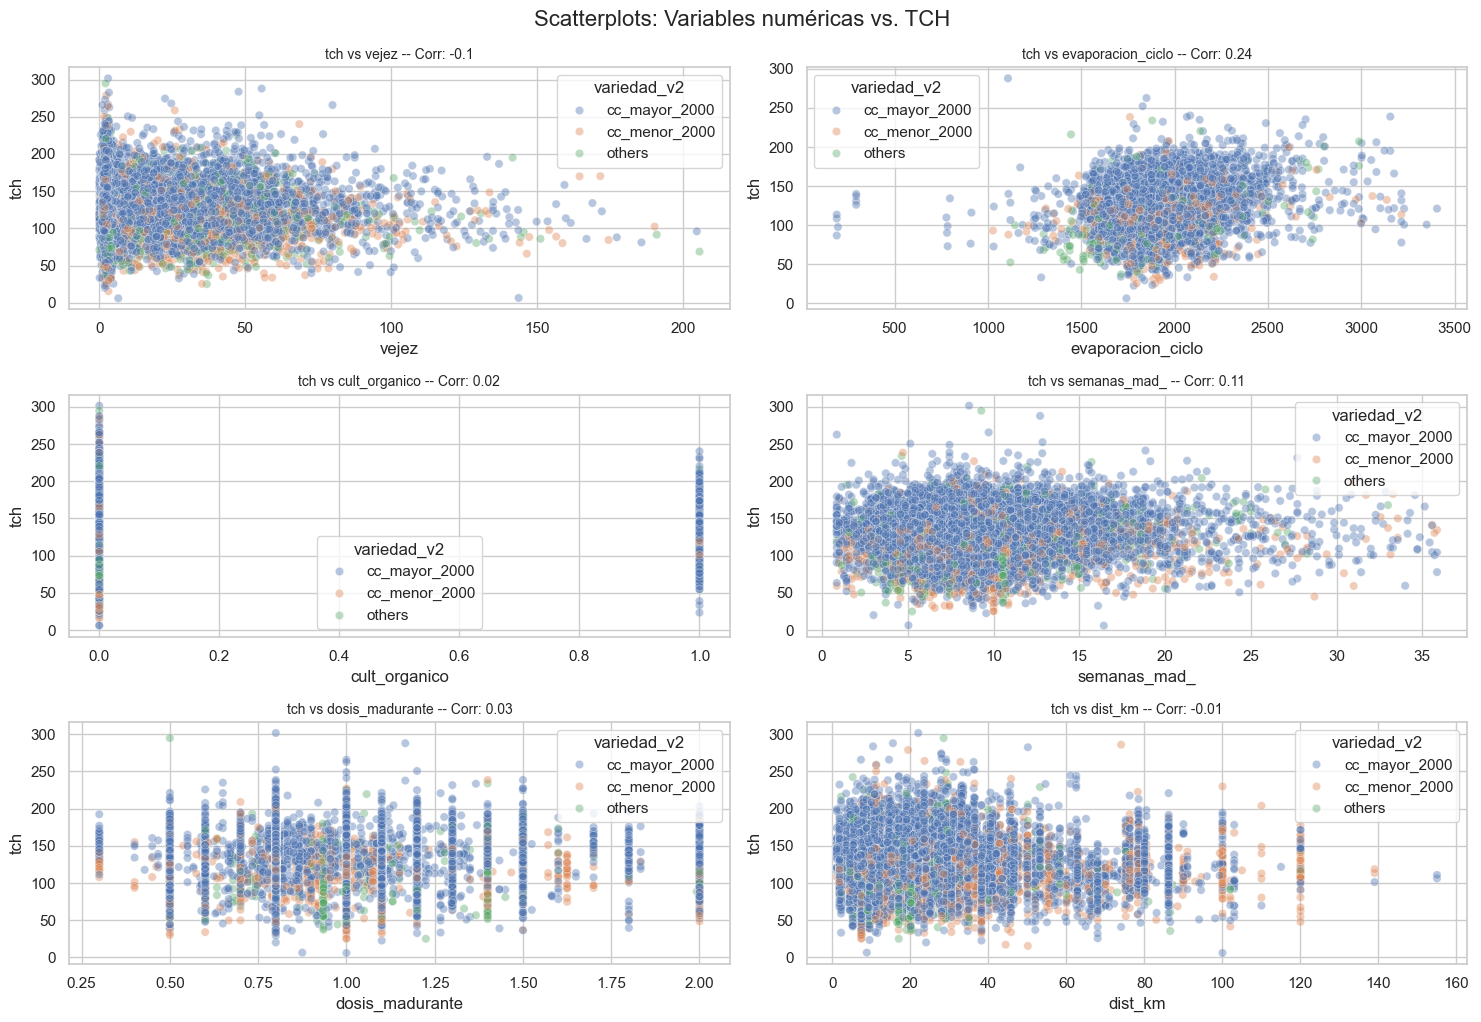

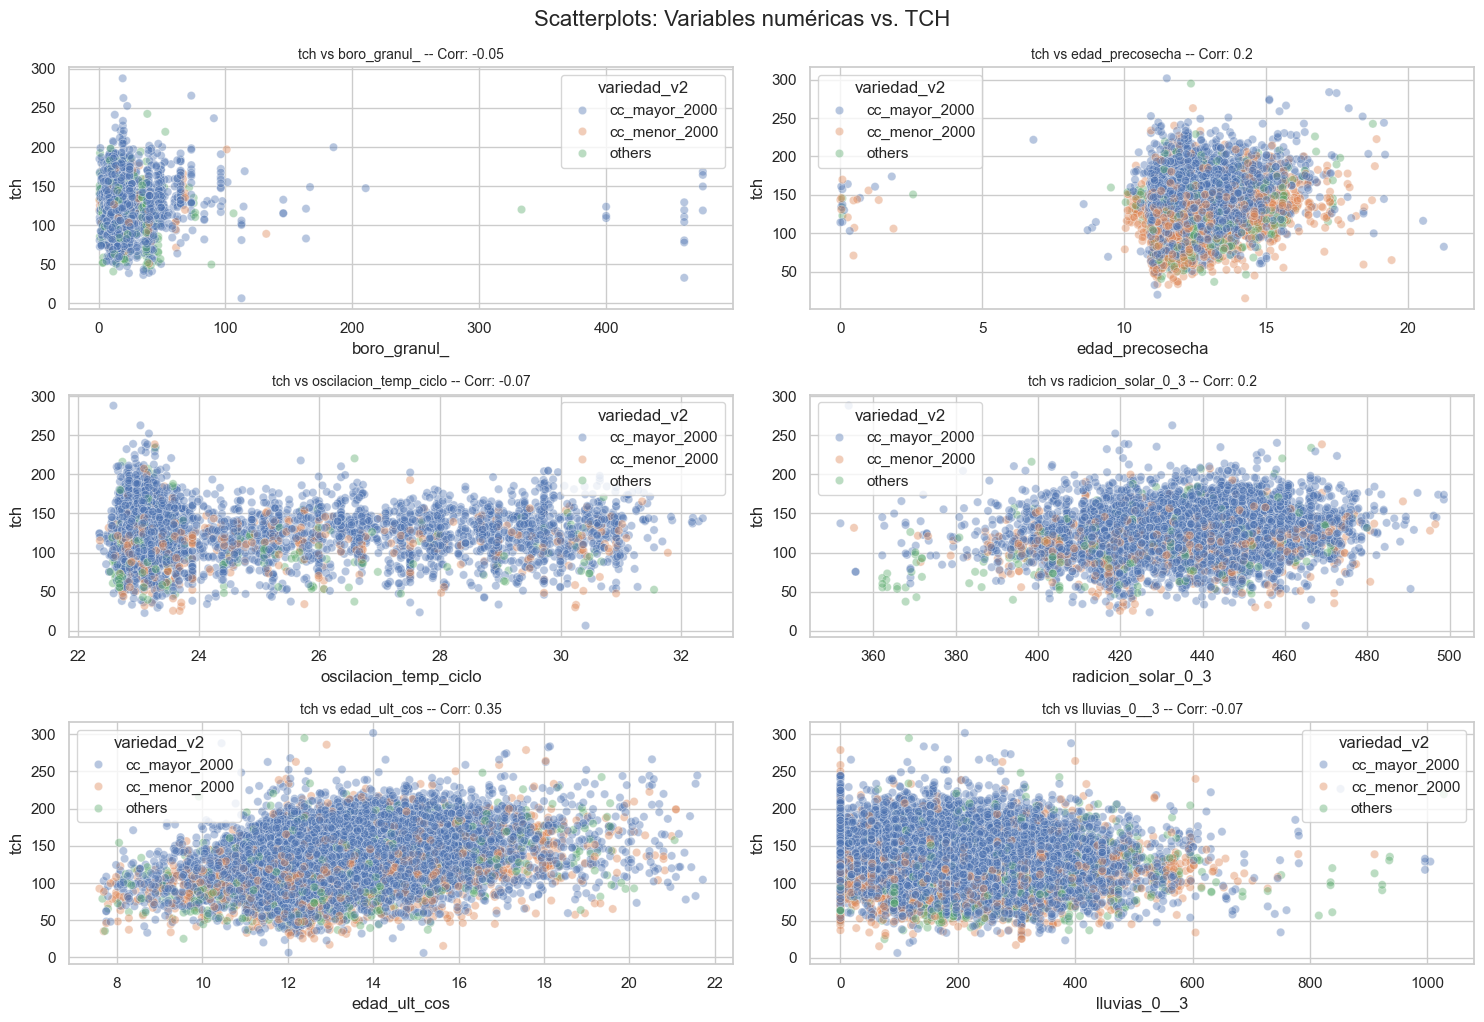

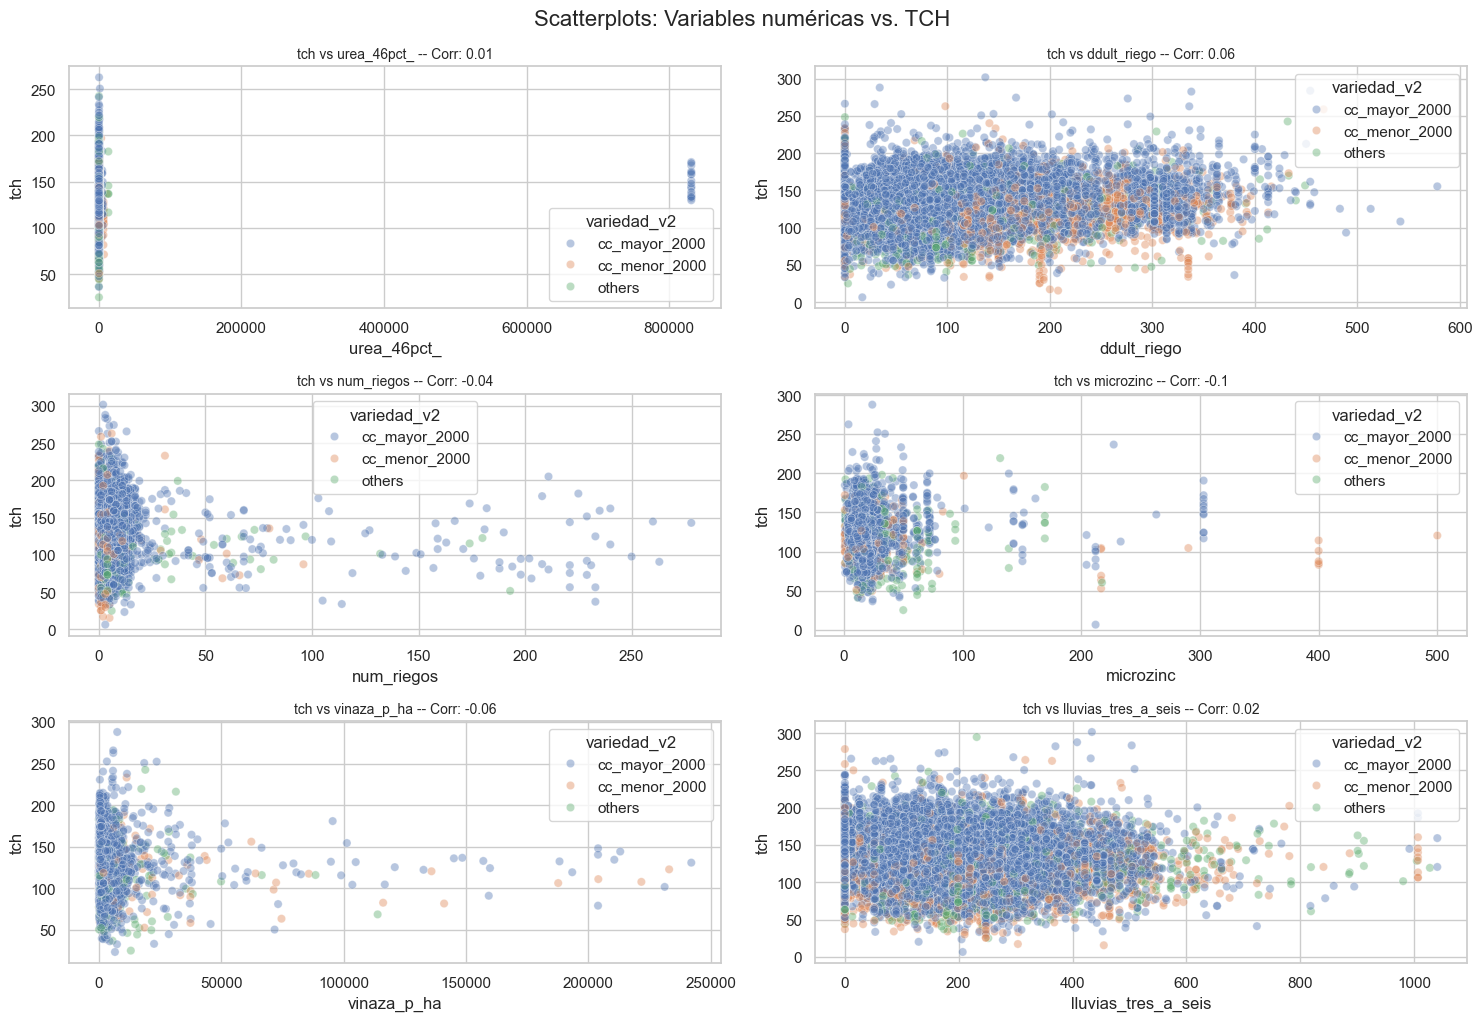

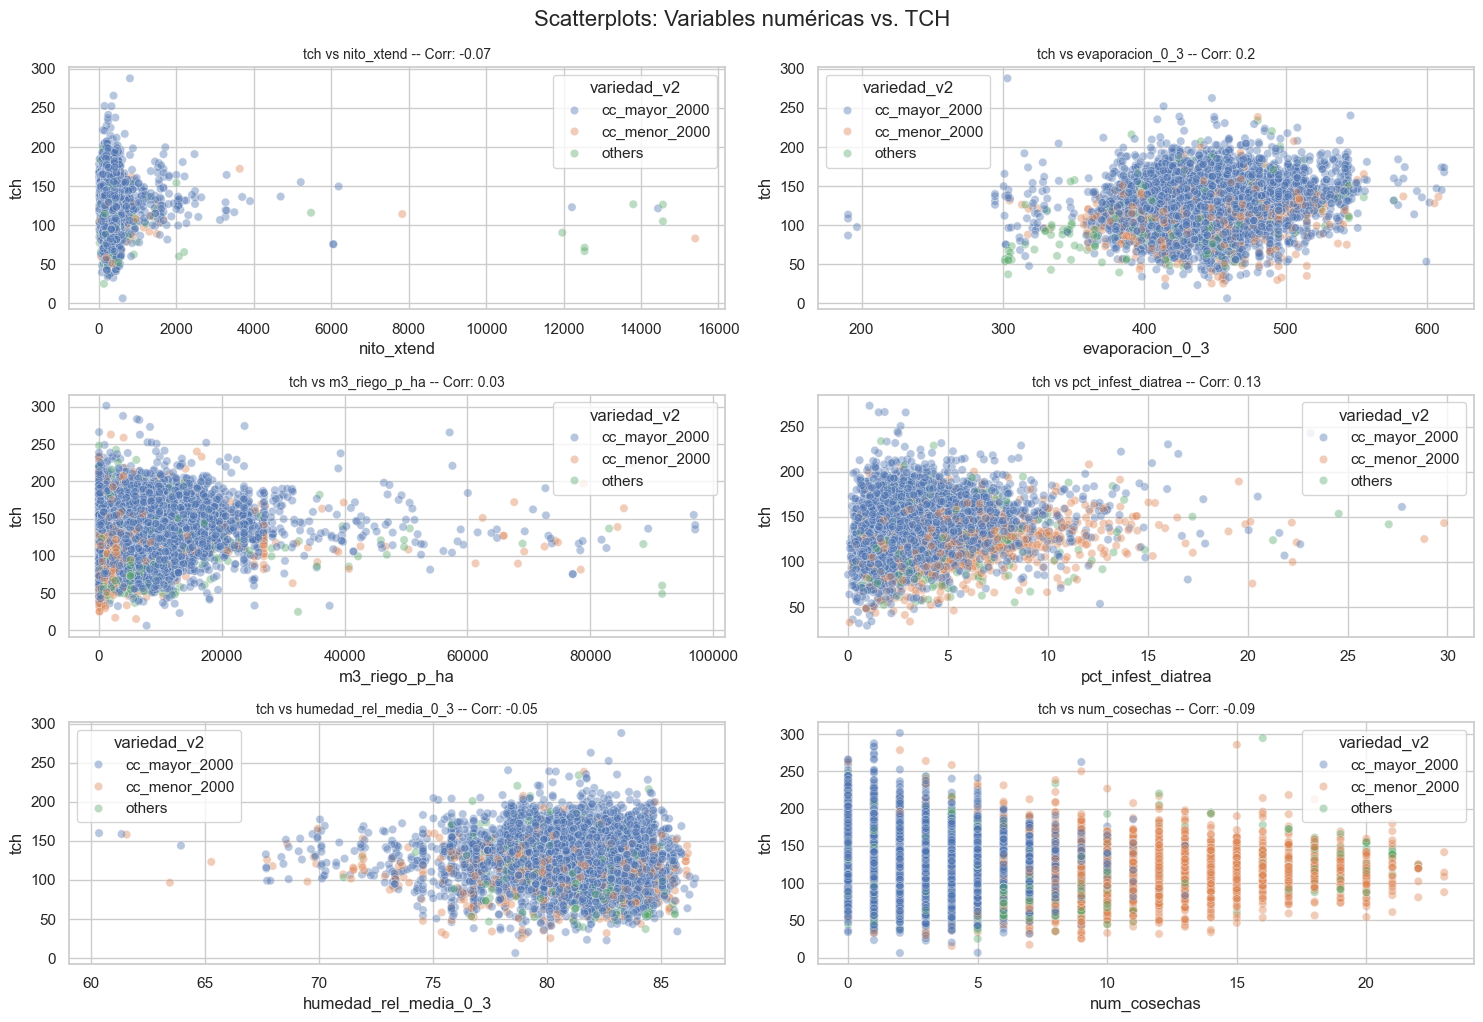

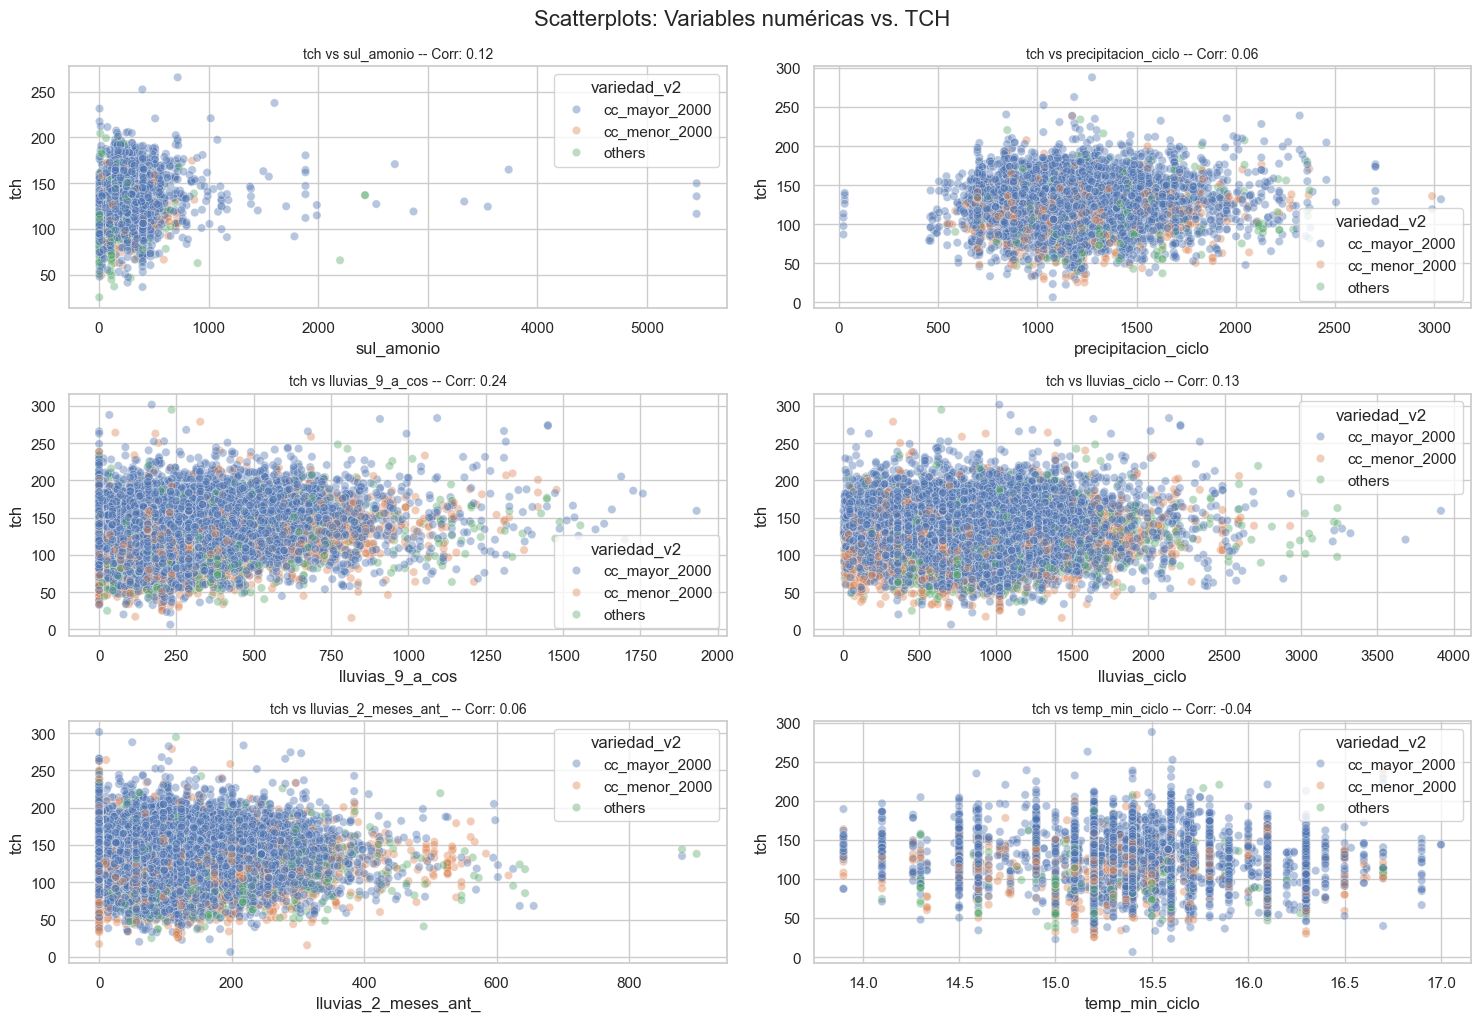

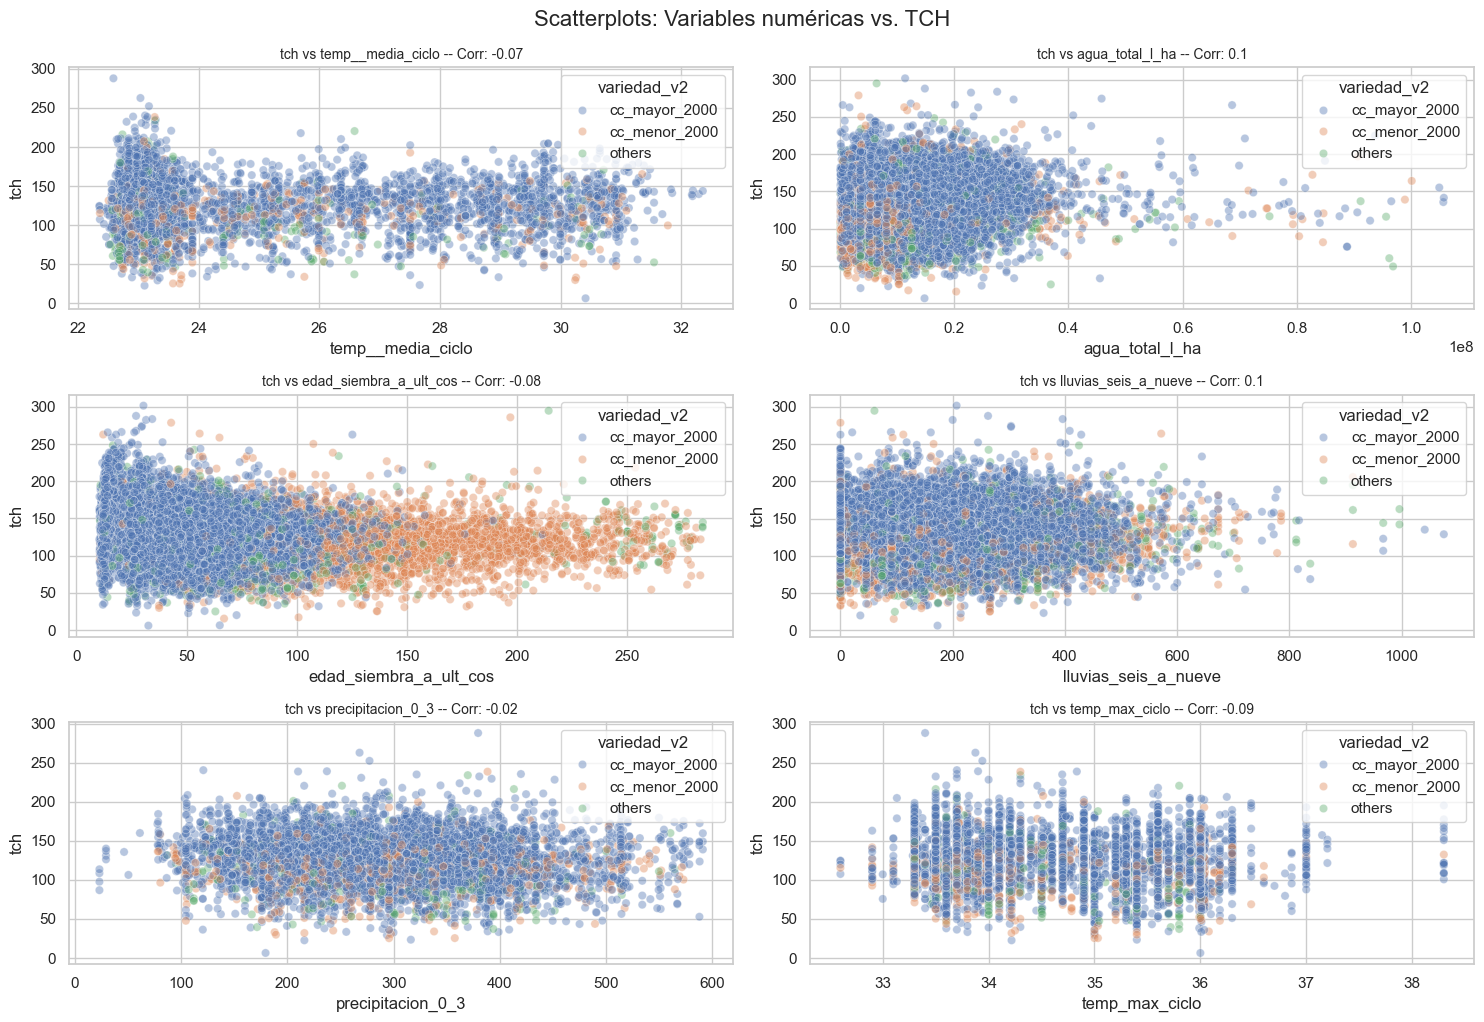

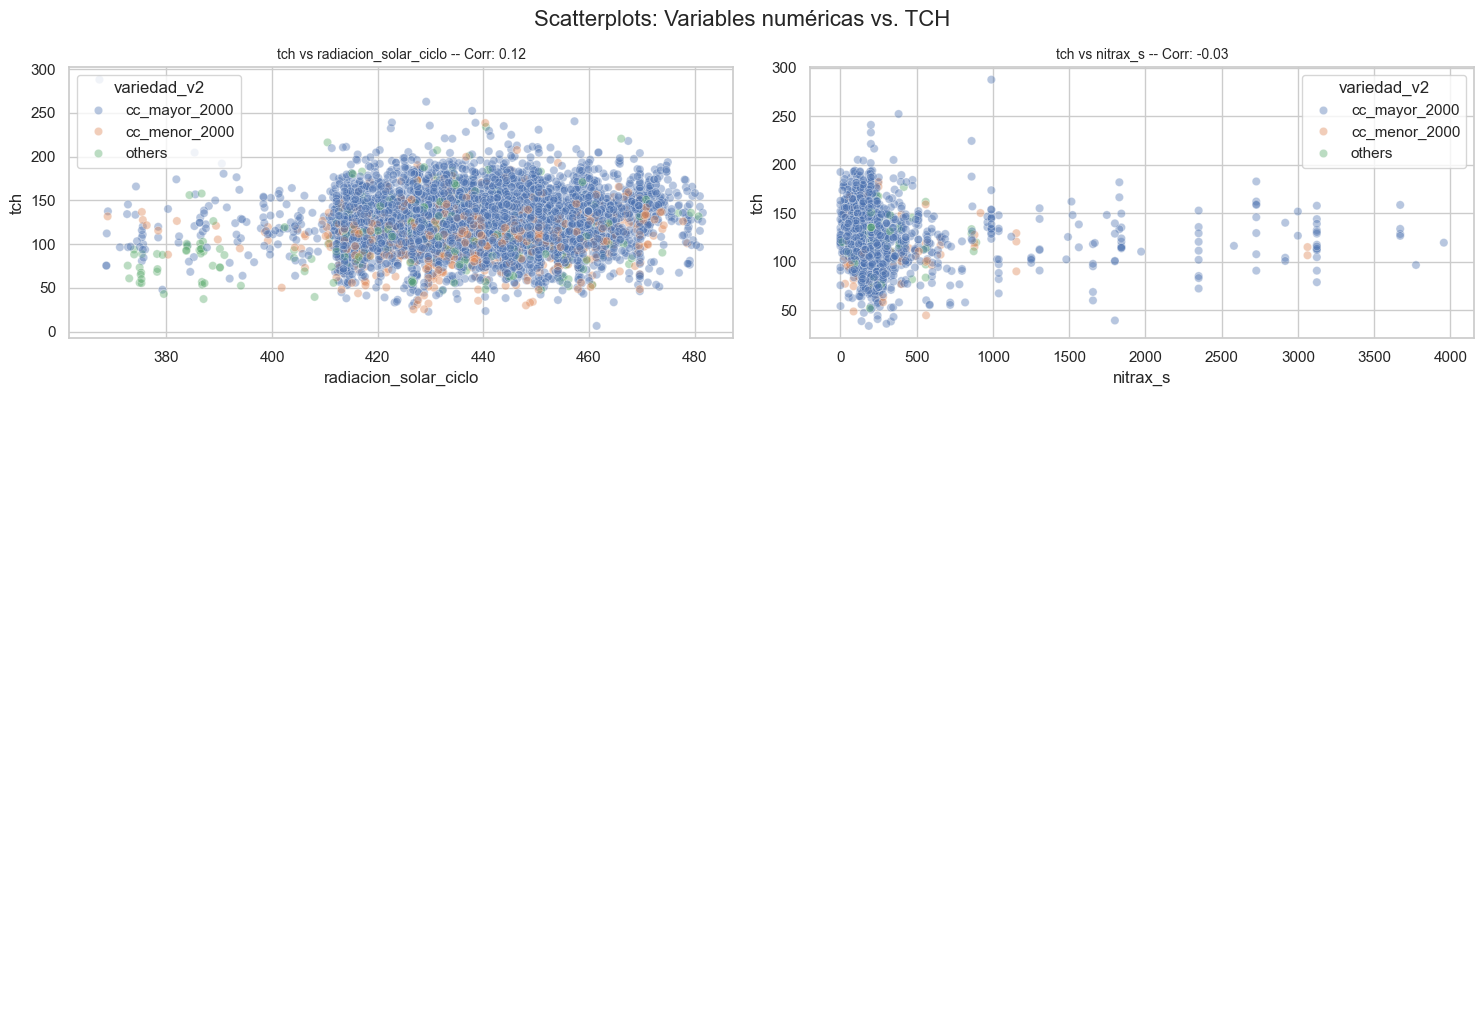

In [106]:
# 6. Scatterplots de algunas variables numéricas con TCH
import math

target = "tch"
num_cols = (
    df.select_dtypes(include=["float64", "int64"]).columns.drop(["tch"]).to_list()
)

columns_to_drop = corr_target[abs(corr_target) < 0.01].index.tolist()

num_cols = list(set(num_cols) - set(columns_to_drop))

# Bloques de 6 gráficos
cols_per_fig = 2
rows_per_fig = 3
plots_per_fig = cols_per_fig * rows_per_fig

for i in range(0, len(num_cols), plots_per_fig):
    subset = num_cols[i : i + plots_per_fig]
    fig, axes = plt.subplots(rows_per_fig, cols_per_fig, figsize=(15, 10))
    axes = axes.flatten()

    for j, col in enumerate(subset):
        corr = corr_target.loc[col]
        sns.scatterplot(
            data=df, x=col, y=target, alpha=0.4, hue="variedad_v2", ax=axes[j]
        )
        axes[j].set_title(f"{target} vs {col} -- Corr: {round(corr,2)}", fontsize=10)

    # Ocultar ejes vacíos (si hay)
    for k in range(j + 1, len(axes)):
        axes[k].axis("off")

    plt.tight_layout()
    plt.suptitle("Scatterplots: Variables numéricas vs. TCH", fontsize=16, y=1.02)
    plt.show()